In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Hệ thống Recommendation cho Uniqlo
## Đồ án DS300 - Multimodal Recommendation Systems

### Tổng quan
Notebook này triển khai và so sánh **6 phương pháp recommendation** khác nhau:

#### 1. **Content-Based Filtering** (Mới)
- Sử dụng đặc trưng nội dung sản phẩm (text + image embeddings)
- Xây dựng user profile từ trung bình các item đã tương tác
- Đề xuất items tương tự với profile của user
- **Ưu điểm**: Không cần dữ liệu tương tác từ users khác, giải quyết cold-start cho items mới
- **Nhược điểm**: Giới hạn trong việc khám phá items khác biệt

#### 2. **User-Based Collaborative Filtering** (Mới)
- Tìm users tương tự dựa trên lịch sử tương tác
- Đề xuất items mà users tương tự đã thích
- Sử dụng cosine similarity giữa user vectors
- **Ưu điểm**: Đơn giản, dễ giải thích, không cần item features
- **Nhược điểm**: Khó mở rộng với nhiều users, cold-start cho users mới

#### 3. **NGCF** (Neural Graph Collaborative Filtering)
- Graph neural network trên bipartite user-item graph
- Học embeddings thông qua message passing với transformations phi tuyến
- BPR loss cho implicit feedback

#### 4. **LightGCN**
- Simplified graph convolution cho recommendation
- Không dùng feature transformation hay non-linearity
- Chỉ dựa vào graph structure

#### 5. **MMGCN** (Multimodal Graph Convolution)
- Tích hợp multimodal features (text + image)
- Propagation riêng biệt cho mỗi modality
- Fusion bằng learnable gate

#### 6. **LightGCL-Multimodal**
- Kết hợp local structure (graph) và global structure (SVD)
- Contrastive learning giữa local và global views
- Multimodal item initialization

### Metrics đánh giá

Tất cả models được đánh giá bằng **4 metrics** chính:

1. **Recall@K**: Tỉ lệ test items xuất hiện trong top-K recommendations
   - Đo khả năng tìm lại item đúng
   - Recall@K = 1 nếu item trong top-K, ngược lại = 0
   
2. **Precision@K** (Mới): Tỉ lệ items relevant trong top-K recommendations
   - Với leave-one-out (1 item đúng): Precision@K = 1/K nếu item trong top-K, ngược lại = 0
   - Đo độ chính xác của recommendations
   - Precision cao → ít false positives
   
3. **NDCG@K**: Normalized Discounted Cumulative Gain
   - Đánh giá chất lượng ranking, ưu tiên vị trí cao hơn
   - NDCG@K = 1/log₂(rank+1) tại vị trí của item đúng
   
4. **MRR@K**: Mean Reciprocal Rank
   - Reciprocal của vị trí đầu tiên xuất hiện item đúng
   - MRR@K = 1/rank nếu item trong top-K, ngược lại = 0
   - Đo tốc độ tìm thấy item đúng

**So sánh Recall vs Precision:**
- Recall@K: Tìm được item không? (recall = coverage)
- Precision@K: Có bao nhiêu % trong top-K là đúng? (precision = accuracy)
- Với K nhỏ (5): Precision quan trọng hơn (user chỉ xem vài items đầu)
- Với K lớn (20): Recall quan trọng hơn (tìm được item là được)

### Cấu trúc Code

1. **Data Loading & Preprocessing**: Load reviews và products, mapping IDs
2. **Feature Extraction**: Text embeddings (Sentence-BERT) + Image embeddings (CLIP)
3. **Train/Test Split**: Leave-one-out evaluation
4. **Model Training**: Train từng model với BPR loss hoặc similarity-based
5. **Evaluation**: Đánh giá với Recall, Precision, NDCG, MRR tại K=[5,10,20]
6. **Comparison**: So sánh performance của tất cả models

### Yêu cầu

```
torch
numpy
pandas
scipy
scikit-learn
sentence-transformers
open_clip_torch
pillow
tqdm
matplotlib
```

### Cách chạy

1. Đảm bảo có đủ packages
2. Cấu hình paths cho data files và image folder
3. Run từng cell theo thứ tự
4. Xem kết quả so sánh ở cuối notebook

## So sánh các phương pháp Recommendation

### Phân loại theo approach:

**1. Content-Based (dựa vào nội dung)**
- **Content-Based Filtering**: Chỉ sử dụng đặc trưng sản phẩm (text + image)

**2. Collaborative Filtering (dựa vào hành vi)**
- **User-Based CF**: Tìm users tương tự, đề xuất items họ thích
- **LightGCN**: Graph convolution đơn giản trên user-item graph
- **NGCF**: Graph neural network với transformations phức tạp

**3. Hybrid/Multimodal (kết hợp cả hai)**
- **MMGCN**: Graph propagation + multimodal features
- **LightGCL**: Local graph + global structure + contrastive learning

### Điểm mạnh/yếu:

| Phương pháp | Điểm mạnh | Điểm yếu | Use Case |
|------------|-----------|----------|----------|
| **Content-Based** | • Cold-start cho items mới<br>• Giải thích được<br>• Không cần nhiều users | • Giới hạn diversity<br>• Phụ thuộc chất lượng features | Items mới, ít users |
| **User-Based CF** | • Đơn giản, dễ hiểu<br>• Không cần item features<br>• Tận dụng "wisdom of crowd" | • Scalability thấp<br>• Cold-start cho users mới<br>• Sparse data | Hệ thống nhỏ, dense data |
| **LightGCN** | • Đơn giản, hiệu quả<br>• SOTA cho CF<br>• Ít parameters | • Cần nhiều interactions<br>• Không dùng features | Many interactions |
| **NGCF** | • Học high-order connectivity<br>• Phi tuyến phong phú | • Phức tạp hơn LightGCN<br>• Dễ overfit | Complex patterns |
| **MMGCN** | • Tận dụng multimodal info<br>• Cold-start tốt hơn CF thuần | • Cần good features<br>• Phức tạp training | Rich item metadata |
| **LightGCL** | • Kết hợp local + global<br>• Contrastive learning<br>• SOTA performance | • Training phức tạp nhất<br>• Computational cost cao | Production systems |

### Khi nào dùng phương pháp nào?

- **Ít data, items mới nhiều** → Content-Based
- **Data dense, hệ thống nhỏ** → User-Based CF  
- **Nhiều interactions, simple baseline** → LightGCN
- **Có rich features (text/image)** → MMGCN
- **Production, cần SOTA** → LightGCL
- **Cần tìm hiểu patterns phức tạp** → NGCF

In [2]:
!pip install open_clip_torch pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.4 MB/s eta 0:00:00


In [3]:
from __future__ import annotations

import os
import re
import math
import json
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import scipy.sparse as sp

# sklearn for PCA + scaling
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Torch stack for  / MMGCN / LightGCL
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
import time

In [4]:
# -----------------------------
# Configuration
# -----------------------------
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

REVIEWS_CSV = "/content/drive/MyDrive/DS300_drive/uniqlo_review_with_id.csv"
PRODUCTS_CSV = "/content/drive/MyDrive/DS300_drive/uniqlo_product_with_images.csv"

# Set this to your local folder containing product images.
# If product_img column already includes relative paths, this is used as a prefix.
IMAGE_ROOT = "/content/drive/MyDrive/DS300_drive/product_img"

POS_THRESHOLD = 3

# Encoders / PCA
TEXT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"  # EN+VI
TEXT_EMB_DIM_RAW = 384   # typical for all-MiniLM-L6-v2
IMG_EMB_DIM_RAW  = 512   # typical for CLIP ViT-B/32
# PCA_TEXT_DIM = 64
# PCA_IMG_DIM = 64

# Training splits / sampling
BATCH_SIZE_BPR = 2048
EPOCHS_GNN = 50
LR_GNN = 1e-3

# Evaluation
TOPKS = [5, 10, 20]

In [5]:
# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [6]:
# -----------------------------
# Data loading / preprocessing
# -----------------------------
def _safe_str(x) -> str:
    if pd.isna(x):
        return ""
    return str(x)

def load_data(reviews_path: str, products_path: str) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_r = pd.read_csv(reviews_path)
    df_p = pd.read_csv(products_path)
    return df_r, df_p

def clean_rating_to_int(s) -> int:
    if pd.isna(s):
        return 0
    if isinstance(s, (int, np.integer)):
        return int(s)
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else 0

def build_id_maps(df_reviews: pd.DataFrame, df_products: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[int,int], Dict[str,int], Dict[int,int]]:
    """
    Returns:
      - filtered reviews with mapped user_id/item_id
      - filtered products with mapped item_id
      - reviewer_id->user_id map
      - product_code->item_id map
      - item_id->product_row_index map
    """
    df = df_reviews.copy()
    df["Rating_int"] = df["Rating"].apply(clean_rating_to_int)

    # Ensure necessary columns
    if "reviewer_id" not in df.columns:
        raise ValueError("reviews CSV must contain reviewer_id")
    if "Mã sản phẩm" not in df.columns:
        raise ValueError("reviews CSV must contain 'Mã sản phẩm'")

    # Product codes
    df_products = df_products.copy()
    if "Mã sản phẩm" not in df_products.columns:
        raise ValueError("products CSV must contain 'Mã sản phẩm'")

    # Build item map from product table
    product_codes = df_products["Mã sản phẩm"].astype(str).unique().tolist()
    product_to_item = {code: idx for idx, code in enumerate(product_codes)}

    # Filter reviews to products we have
    df["product_code"] = df["Mã sản phẩm"].astype(str)
    df = df[df["product_code"].isin(product_to_item)].copy()

    # Map users
    reviewer_ids = df["reviewer_id"].astype(int).unique().tolist()
    reviewer_to_user = {rid: idx for idx, rid in enumerate(reviewer_ids)}

    df["user_id"] = df["reviewer_id"].astype(int).map(reviewer_to_user).astype(int)
    df["item_id"] = df["product_code"].map(product_to_item).astype(int)

    # Align products to item_id
    df_products["product_code"] = df_products["Mã sản phẩm"].astype(str)
    df_products = df_products[df_products["product_code"].isin(product_to_item)].copy()
    df_products["item_id"] = df_products["product_code"].map(product_to_item).astype(int)
    df_products = df_products.sort_values("item_id").drop_duplicates("item_id").reset_index(drop=True)

    itemid_to_prodrow = {int(r.item_id): int(i) for i, r in df_products.iterrows()}

    return df, df_products, reviewer_to_user, product_to_item, itemid_to_prodrow

def build_implicit_positives(df_reviews_mapped: pd.DataFrame, pos_threshold: int) -> pd.DataFrame:
    df_pos = df_reviews_mapped[df_reviews_mapped["Rating_int"] >= pos_threshold].copy()
    # Keep only one interaction per (user,item) (implicit)
    df_pos = df_pos.drop_duplicates(["user_id", "item_id"])
    return df_pos[["user_id", "item_id"]].reset_index(drop=True)

def leave_one_out_split(df_pos: pd.DataFrame, seed: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    For each user with >=2 positives, hold out 1 random positive for test.
    Users with 1 positive remain in train only.
    """
    rng = np.random.default_rng(seed)
    test_rows = []
    train_rows = []

    grouped = df_pos.groupby("user_id")["item_id"].apply(list)
    for u, items in grouped.items():
        if len(items) >= 2:
            t = int(rng.choice(items, size=1)[0])
            test_rows.append((u, t))
            for it in items:
                if it != t:
                    train_rows.append((u, int(it)))
        else:
            for it in items:
                train_rows.append((u, int(it)))

    train_df = pd.DataFrame(train_rows, columns=["user_id", "item_id"])
    test_df = pd.DataFrame(test_rows, columns=["user_id", "item_id"])
    return train_df, test_df

def build_train_pos_dict(train_df: pd.DataFrame) -> Dict[int, set]:
    d: Dict[int, set] = {}
    for u, i in zip(train_df["user_id"].values, train_df["item_id"].values):
        d.setdefault(int(u), set()).add(int(i))
    return d

def build_interaction_csr(train_df: pd.DataFrame, num_users: int, num_items: int) -> sp.csr_matrix:
    rows = train_df["user_id"].astype(int).values
    cols = train_df["item_id"].astype(int).values
    data = np.ones(len(rows), dtype=np.float32)
    R = sp.coo_matrix((data, (rows, cols)), shape=(num_users, num_items)).tocsr()
    return R

In [7]:
# -----------------------------
# Modality encoders (Text/Image) + PCA
# -----------------------------
def build_item_text_corpus(df_products, use_description: bool = True, use_material: bool = True, use_product_name: bool = True):
    """
    Build text for each product.
    Ablation: if use_description=False, the product description field is excluded.
    *Lưu ý: Các thuộc tính được thêm vào có tiêu đề thuần tiếng Việt
    """
    texts = []
    for _, row in df_products.iterrows():
        # Adjust these column names to exactly match your CSV
        if use_product_name:
          name = str(row.get("Tên sản phẩm", "")).strip()
        else:
          name = ""

        if use_material:
          material = str(row.get("Chất liệu", "")).strip()
        else:
          material = ""

        if use_description:
            desc = str(row.get("Mô tả", "")).strip()
        else:
            desc = ""  # ablation: drop description

        # Combine fields (keep the exact style you used originally if possible)
        # Using simple whitespace join and stripping extra spaces
        text = " ".join([name, desc, material]).strip()
        texts.append(text)

    return texts

def encode_text_sentence_transformer(texts: List[str], batch_size: int = 64) -> np.ndarray:
    """
    Uses SentenceTransformer. Requires internet to download weights if not cached.
    """
    try:
        from sentence_transformers import SentenceTransformer
    except Exception as e:
        raise RuntimeError("Please install sentence-transformers (pip install sentence-transformers)") from e

    model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
    # Optional GPU: move model if CUDA is available
    if DEVICE == "cuda":
        model = model.to(DEVICE)
    embs = model.encode(texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=False)
    return embs.astype(np.float32)

def resolve_image_path(row: pd.Series) -> Optional[str]:
    """
    Try to resolve local image path:
    - If product_img column exists and is a path/filename, join with IMAGE_ROOT if relative.
    - Else, try IMAGE_ROOT/<product_code>.(jpg|png|jpeg|webp)
    """
    product_code = _safe_str(row.get("product_code", ""))
    pcol = row.get("product_img", None)
    candidates = []

    if isinstance(pcol, str) and pcol.strip():
        p = pcol.strip()
        if not os.path.isabs(p):
            p = os.path.join(IMAGE_ROOT, p)
        candidates.append(p)

    # fallback by product code
    for ext in ["jpg", "jpeg", "png", "webp"]:
        candidates.append(os.path.join(IMAGE_ROOT, f"{product_code}.{ext}"))
        candidates.append(os.path.join(IMAGE_ROOT, product_code, f"0.{ext}"))  # common pattern: folder per product
        candidates.append(os.path.join(IMAGE_ROOT, product_code, f"1.{ext}"))

    for p in candidates:
        if p and os.path.exists(p):
            return p
    return None

def encode_images_openclip(df_products: pd.DataFrame, batch_size: int = 64) -> np.ndarray:
    """
    Encodes local images using OpenCLIP.
    Requires:
      pip install open_clip_torch pillow
    """
    try:
        import open_clip
        from PIL import Image
    except Exception as e:
        raise RuntimeError("Please install open_clip_torch and pillow (pip install open_clip_torch pillow)") from e

    model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    model = model.to(DEVICE).eval()

    paths = [resolve_image_path(r) for _, r in df_products.iterrows()]
    # Use a learned fallback by returning zeros for missing; later we can learn a missing token
    embs = np.zeros((len(paths), IMG_EMB_DIM_RAW), dtype=np.float32)

    with torch.no_grad():
        batch_imgs = []
        batch_idx = []
        for idx, p in tqdm(list(enumerate(paths)), desc="[OpenCLIP] Encoding images", total=len(paths)):
            if p is None:
                continue
            try:
                img = Image.open(p).convert("RGB")
                batch_imgs.append(preprocess(img))
                batch_idx.append(idx)
            except Exception:
                continue

            if len(batch_imgs) == batch_size:
                x = torch.stack(batch_imgs, dim=0).to(DEVICE)
                feat = model.encode_image(x)
                feat = feat.float().cpu().numpy()
                # If dim differs, keep min dims
                d = min(feat.shape[1], IMG_EMB_DIM_RAW)
                embs[np.array(batch_idx), :d] = feat[:, :d]
                batch_imgs, batch_idx = [], []

        if batch_imgs:
            x = torch.stack(batch_imgs, dim=0).to(DEVICE)
            feat = model.encode_image(x)
            feat = feat.float().cpu().numpy()
            d = min(feat.shape[1], IMG_EMB_DIM_RAW)
            embs[np.array(batch_idx), :d] = feat[:, :d]

    return embs

def fit_pca(X: np.ndarray, out_dim: int, seed: int = 42) -> Tuple[np.ndarray, PCA]:
    out_dim = min(out_dim, X.shape[1])
    pca = PCA(n_components=out_dim, random_state=seed)
    Z = pca.fit_transform(X)
    return Z.astype(np.float32), pca

def apply_pca(X: np.ndarray, pca: PCA) -> np.ndarray:
    return pca.transform(X).astype(np.float32)

In [8]:
# -----------------------------
# Metrics / Evaluation
# -----------------------------
def recall_at_k(gt_item: int, recs: List[int], k: int) -> float:
    return 1.0 if gt_item in recs[:k] else 0.0

def precision_at_k(gt_item: int, recs: List[int], k: int) -> float:
    """
    Precision at K
    For leave-one-out evaluation with single ground truth item:
    Precision@K = 1/K if gt_item in top-K, else 0
    """
    return 1.0 / k if gt_item in recs[:k] else 0.0

def ndcg_at_k(gt_item: int, recs: List[int], k: int) -> float:
    topk = recs[:k]
    if gt_item not in topk:
        return 0.0
    rank = topk.index(gt_item) + 1
    return 1.0 / math.log2(rank + 1)

def mrr_at_k(gt_item: int, recs: List[int], k: int) -> float:
    """Mean Reciprocal Rank at K"""
    topk = recs[:k]
    if gt_item not in topk:
        return 0.0
    rank = topk.index(gt_item) + 1
    return 1.0 / rank

@torch.no_grad()
def evaluate_from_score_fn(
    score_user_items_fn,
    test_df: pd.DataFrame,
    train_pos: Dict[int, set],
    num_items: int,
    topks: List[int],
    batch_users: int = 256,
) -> Dict[str, float]:
    """
    score_user_items_fn(u_batch: np.ndarray[int]) -> np.ndarray[batch, num_items]
    """
    metrics = {f"Recall@{k}": 0.0 for k in topks}
    metrics.update({f"Precision@{k}": 0.0 for k in topks})
    metrics.update({f"NDCG@{k}": 0.0 for k in topks})
    metrics.update({f"MRR@{k}": 0.0 for k in topks})
    n = 0

    test_users = test_df["user_id"].astype(int).values
    test_items = test_df["item_id"].astype(int).values

    # batch users for speed
    idx = 0
    while idx < len(test_users):
        ub = test_users[idx:idx+batch_users]
        itb = test_items[idx:idx+batch_users]
        scores = score_user_items_fn(ub)  # [B, I]

        # mask training positives per user
        for b, u in enumerate(ub):
            seen = train_pos.get(int(u), set())
            if seen:
                scores[b, list(seen)] = -1e9

        # top maxK
        maxK = max(topks)
        topk_idx = np.argpartition(-scores, kth=maxK-1, axis=1)[:, :maxK]
        # sort those topK indices by score
        topk_sorted = []
        for b in range(topk_idx.shape[0]):
            cand = topk_idx[b]
            cand = cand[np.argsort(-scores[b, cand])]
            topk_sorted.append(cand.tolist())

        for b in range(len(ub)):
            gt = int(itb[b])
            recs = topk_sorted[b]
            for k in topks:
                metrics[f"Recall@{k}"] += recall_at_k(gt, recs, k)
                metrics[f"Precision@{k}"] += precision_at_k(gt, recs, k)
                metrics[f"NDCG@{k}"] += ndcg_at_k(gt, recs, k)
                metrics[f"MRR@{k}"] += mrr_at_k(gt, recs, k)
            n += 1

        idx += batch_users

    for k in topks:
        metrics[f"Recall@{k}"] /= max(n, 1)
        metrics[f"Precision@{k}"] /= max(n, 1)
        metrics[f"NDCG@{k}"] /= max(n, 1)
        metrics[f"MRR@{k}"] /= max(n, 1)
    return metrics

In [9]:
# ============================================================
# 1) NGCF (Neural Graph Collaborative Filtering)
# ============================================================
class NGCF(nn.Module):
    """
    NGCF for bipartite user-item graph.

    Update:
      neigh = A @ E
      E_{k+1} = LeakyReLU( W1(neigh) + W2(neigh ⊙ E_k) )
      then dropout + l2-norm.

    Final embedding = mean(E^{0..L}) (stable; common in NGCF re-implementations).
    Training strategy: same as MMGCN/LightGCL (BPR + uniform negative sampling).
    """
    def __init__(self, num_users, num_items, emb_dim, layers, adj_norm_bipartite: torch.Tensor,
                 dropout=0.1, edge_dropout=0.1):
        super().__init__()
        self.U = num_users
        self.I = num_items
        self.D = emb_dim
        self.L = layers
        self.dropout = dropout
        self.edge_dropout = edge_dropout

        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

        self.W1 = nn.ModuleList([nn.Linear(emb_dim, emb_dim, bias=True) for _ in range(layers)])
        self.W2 = nn.ModuleList([nn.Linear(emb_dim, emb_dim, bias=True) for _ in range(layers)])
        self.act = nn.LeakyReLU(0.2)

        self.adj = adj_norm_bipartite.coalesce().to(DEVICE)

    def _edge_dropout(self, adj: torch.Tensor) -> torch.Tensor:
        if self.edge_dropout <= 0:
            return adj
        adj = adj.coalesce()
        nnz = adj.values().numel()
        keep_prob = 1.0 - self.edge_dropout
        mask = torch.rand(nnz, device=adj.device) < keep_prob
        new_indices = adj.indices()[:, mask]
        new_values = adj.values()[mask] / keep_prob
        return torch.sparse_coo_tensor(new_indices, new_values, adj.shape).coalesce()

    def forward(self) -> Tuple[torch.Tensor, torch.Tensor]:
        A = self._edge_dropout(self.adj)
        E0 = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)  # [U+I, D]
        outs = [E0]
        E = E0
        for l in range(self.L):
            neigh = torch.sparse.mm(A, E)
            out = self.act(self.W1[l](neigh) + self.W2[l](neigh * E))
            out = F.dropout(out, p=self.dropout, training=self.training)
            out = F.normalize(out, dim=1)
            E = out
            outs.append(E)
        E_final = torch.mean(torch.stack(outs, dim=0), dim=0)
        Eu, Ei = torch.split(E_final, [self.U, self.I], dim=0)
        return Eu, Ei

def train_ngcf(
    R_train: sp.csr_matrix,
    train_pos: Dict[int, set],
    num_users: int,
    num_items: int,
) -> NGCF:
    adj = build_norm_adj_from_R(R_train).to(DEVICE)
    model = NGCF(num_users, num_items, emb_dim=64, layers=2, adj_norm_bipartite=adj,
                 dropout=0.1, edge_dropout=0.1).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR_GNN, weight_decay=1e-4)
    rng = np.random.default_rng(SEED)

    model.train()
    for ep in range(1, EPOCHS_GNN + 1):
        t0 = time.time()
        steps = max(1, len(train_pos) * 5 // BATCH_SIZE_BPR)
        total = 0.0
        pbar = tqdm(range(steps), desc=f"[NGCF] epoch {ep:03d}/{EPOCHS_GNN}")
        for _ in pbar:
            users, pos, neg = sample_bpr_batch(train_pos, num_items, BATCH_SIZE_BPR, rng)
            Eu, Ei = model()
            loss = bpr_loss(Eu, Ei, users, pos, neg)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += float(loss.item())
            pbar.set_postfix(loss=float(loss.item()))
        print(f"[NGCF] epoch {ep:03d} avg_loss={total/max(steps,1):.4f} time={time.time()-t0:.1f}s")
    return model

In [10]:
# ============================================================
# 2) LightGCN (pure CF graph baseline)
# ============================================================
class LightGCN(nn.Module):
    """
    LightGCN on bipartite user-item graph.
    - No feature transforms / nonlinearities.
    - Final embedding = mean(E^{0..L}).
    Training strategy: identical to MMGCN/LightGCL here (BPR + uniform negative sampling).
    """
    def __init__(self, num_users, num_items, emb_dim, layers, adj_norm_bipartite: torch.Tensor, edge_dropout=0.1):
        super().__init__()
        self.U = num_users
        self.I = num_items
        self.D = emb_dim
        self.L = layers
        self.edge_dropout = edge_dropout

        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.item_emb = nn.Embedding(num_items, emb_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

        self.adj = adj_norm_bipartite.coalesce().to(DEVICE)

    def _edge_dropout(self, adj: torch.Tensor) -> torch.Tensor:
        if self.edge_dropout <= 0:
            return adj
        adj = adj.coalesce()
        nnz = adj.values().numel()
        keep_prob = 1.0 - self.edge_dropout
        mask = torch.rand(nnz, device=adj.device) < keep_prob
        new_indices = adj.indices()[:, mask]
        new_values = adj.values()[mask] / keep_prob
        return torch.sparse_coo_tensor(new_indices, new_values, adj.shape).coalesce()

    def forward(self) -> Tuple[torch.Tensor, torch.Tensor]:
        A = self._edge_dropout(self.adj)
        E0 = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)  # [U+I, D]
        outs = [E0]
        E = E0
        for _ in range(self.L):
            E = torch.sparse.mm(A, E)
            outs.append(E)
        E_final = torch.mean(torch.stack(outs, dim=0), dim=0)
        Eu, Ei = torch.split(E_final, [self.U, self.I], dim=0)
        return Eu, Ei

def train_lightgcn(
    R_train: sp.csr_matrix,
    train_pos: Dict[int, set],
    num_users: int,
    num_items: int,
) -> LightGCN:
    adj = build_norm_adj_from_R(R_train).to(DEVICE)
    model = LightGCN(
        num_users=num_users,
        num_items=num_items,
        emb_dim=64,
        layers=2,
        adj_norm_bipartite=adj,
        edge_dropout=0.1,
    ).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=LR_GNN, weight_decay=1e-4)
    rng = np.random.default_rng(SEED)

    model.train()
    for ep in range(1, EPOCHS_GNN + 1):
        t0 = time.time()
        steps = max(1, len(train_pos) * 5 // BATCH_SIZE_BPR)
        total = 0.0
        pbar = tqdm(range(steps), desc=f"[LightGCN] epoch {ep:03d}/{EPOCHS_GNN}")
        for _ in pbar:
            users, pos, neg = sample_bpr_batch(train_pos, num_items, BATCH_SIZE_BPR, rng)
            Eu, Ei = model()
            loss = bpr_loss(Eu, Ei, users, pos, neg)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += float(loss.item())
            pbar.set_postfix(loss=float(loss.item()))
        print(f"[LightGCN] epoch {ep:03d} avg_loss={total/max(steps,1):.4f} time={time.time()-t0:.1f}s")
    return model

In [11]:
# ============================================================
# 3) MMGCN (img+text only)
# ============================================================
def build_norm_adj_from_R(R: sp.csr_matrix) -> torch.Tensor:
    """
    Normalized adjacency for bipartite graph:
    A = [[0, D_u^{-1/2} R D_i^{-1/2}],
         [D_i^{-1/2} R^T D_u^{-1/2}, 0]]
    """
    U, I = R.shape
    du = np.array(R.sum(axis=1)).flatten()
    di = np.array(R.sum(axis=0)).flatten()
    du_inv_sqrt = np.power(du + 1e-12, -0.5)
    di_inv_sqrt = np.power(di + 1e-12, -0.5)
    Du = sp.diags(du_inv_sqrt)
    Di = sp.diags(di_inv_sqrt)
    R_hat = Du @ R @ Di

    zero_uu = sp.csr_matrix((U, U), dtype=np.float32)
    zero_ii = sp.csr_matrix((I, I), dtype=np.float32)
    A = sp.bmat([[zero_uu, R_hat], [R_hat.T, zero_ii]], format="csr").tocoo()

    indices = torch.tensor([A.row, A.col], dtype=torch.long)
    values = torch.tensor(A.data, dtype=torch.float32)
    return torch.sparse_coo_tensor(indices, values, size=A.shape).coalesce()

class MMGCNImgTxt(nn.Module):
    """
    Practical MMGCN-like model with two modalities (img, txt):
      - item init from W_img X_img and W_txt X_txt
      - user init from mean of neighbor items in each modality
      - propagation (LightGCN-style) per modality for L layers
      - fusion by weighted sum (learnable gate)
      - BPR training
    """
    def __init__(self, num_users, num_items, emb_dim, L, adj_norm, X_img, X_txt):
        super().__init__()
        self.U = num_users
        self.I = num_items
        self.D = emb_dim
        self.L = L
        self.adj = adj_norm

        self.W_img = nn.Linear(X_img.shape[1], emb_dim, bias=False)
        self.W_txt = nn.Linear(X_txt.shape[1], emb_dim, bias=False)

        # learnable fusion gate alpha in (0,1)
        self.alpha_logit = nn.Parameter(torch.tensor(0.0))

        # keep modality features as buffers
        self.register_buffer("X_img", torch.tensor(X_img, dtype=torch.float32))
        self.register_buffer("X_txt", torch.tensor(X_txt, dtype=torch.float32))

        # small ID embeddings for stability (optional)
        self.user_id = nn.Embedding(num_users, emb_dim)
        self.item_id = nn.Embedding(num_items, emb_dim)
        nn.init.xavier_uniform_(self.user_id.weight)
        nn.init.xavier_uniform_(self.item_id.weight)

    def forward_modal(self, item_init: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Perform LightGCN propagation on a bipartite graph for a given modality.
        item_init: [I, D]
        returns (Eu, Ei)
        """
        # init users by mean of neighbor items (one hop), approximate by adj multiplication from items:
        # Build E0 = [U; I]
        Eu0 = self.user_id.weight
        Ei0 = item_init
        E0 = torch.cat([Eu0, Ei0], dim=0)

        outs = [E0]
        E = E0
        for _ in range(self.L):
            E = torch.sparse.mm(self.adj, E)
            outs.append(E)
        E_final = torch.mean(torch.stack(outs, dim=0), dim=0)
        Eu, Ei = torch.split(E_final, [self.U, self.I], dim=0)
        return Eu, Ei

    def forward(self) -> Tuple[torch.Tensor, torch.Tensor]:
        img_item = self.item_id.weight + self.W_img(self.X_img)
        txt_item = self.item_id.weight + self.W_txt(self.X_txt)

        Eu_img, Ei_img = self.forward_modal(img_item)
        Eu_txt, Ei_txt = self.forward_modal(txt_item)

        alpha = torch.sigmoid(self.alpha_logit)
        Eu = alpha * Eu_img + (1 - alpha) * Eu_txt
        Ei = alpha * Ei_img + (1 - alpha) * Ei_txt
        return Eu, Ei

def bpr_loss(Eu, Ei, users, pos_items, neg_items):
    u = Eu[users]
    pi = Ei[pos_items]
    ni = Ei[neg_items]
    pos = torch.sum(u * pi, dim=1)
    neg = torch.sum(u * ni, dim=1)
    return -torch.mean(F.logsigmoid(pos - neg))

def sample_bpr_batch(train_pos: Dict[int, set], num_items: int, batch_size: int, rng: np.random.Generator):
    users = rng.integers(0, len(train_pos), size=batch_size)
    # Map user indices to actual keys for robustness
    user_keys = list(train_pos.keys())
    u = np.array([user_keys[int(x)] for x in users], dtype=np.int64)
    pos = np.array([rng.choice(list(train_pos[int(uu)])) for uu in u], dtype=np.int64)
    neg = np.zeros(batch_size, dtype=np.int64)
    for idx, uu in enumerate(u):
        seen = train_pos[int(uu)]
        j = int(rng.integers(0, num_items))
        while j in seen:
            j = int(rng.integers(0, num_items))
        neg[idx] = j
    return torch.tensor(u, dtype=torch.long, device=DEVICE), torch.tensor(pos, dtype=torch.long, device=DEVICE), torch.tensor(neg, dtype=torch.long, device=DEVICE)

def train_mmgcn(
    R_train: sp.csr_matrix,
    train_pos: Dict[int, set],
    X_img: np.ndarray,
    X_txt: np.ndarray,
    num_users: int,
    num_items: int,
) -> MMGCNImgTxt:
    adj = build_norm_adj_from_R(R_train).to(DEVICE)
    model = MMGCNImgTxt(num_users, num_items, emb_dim=64, L=2, adj_norm=adj, X_img=X_img, X_txt=X_txt).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR_GNN, weight_decay=1e-4)
    rng = np.random.default_rng(SEED)

    model.train()
    for ep in range(1, EPOCHS_GNN + 1):
        steps = max(1, len(train_pos) * 5 // BATCH_SIZE_BPR)
        total = 0.0
        for _ in range(steps):
            users, pos, neg = sample_bpr_batch(train_pos, num_items, BATCH_SIZE_BPR, rng)
            Eu, Ei = model()
            loss = bpr_loss(Eu, Ei, users, pos, neg)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += float(loss.item())
        if ep % 5 == 0 or ep == 1:
            print(f"[MMGCN] epoch {ep:03d} loss={total/max(steps,1):.4f}")
    return model

def make_gnn_score_fn(get_embeddings_fn, num_items: int):
    @torch.no_grad()
    def score_fn(u_batch: np.ndarray) -> np.ndarray:
        Eu, Ei = get_embeddings_fn()
        Eu_np = Eu.detach().cpu().numpy()
        Ei_np = Ei.detach().cpu().numpy()
        return Eu_np[u_batch.astype(np.int64)] @ Ei_np.T
    return score_fn

In [12]:
# ============================================================
# 4) LightGCL-Multimodal
# ============================================================
def build_norm_ui_matrix(R: sp.csr_matrix) -> sp.csr_matrix:
    U, I = R.shape
    du = np.array(R.sum(axis=1)).flatten()
    di = np.array(R.sum(axis=0)).flatten()
    du_inv_sqrt = np.power(du + 1e-12, -0.5)
    di_inv_sqrt = np.power(di + 1e-12, -0.5)
    Du = sp.diags(du_inv_sqrt)
    Di = sp.diags(di_inv_sqrt)
    return (Du @ R @ Di).tocsr()

def sparse_edge_dropout(adj: torch.Tensor, drop_rate: float) -> torch.Tensor:
    if drop_rate <= 0:
        return adj
    adj = adj.coalesce()
    nnz = adj.values().numel()
    keep_prob = 1.0 - drop_rate
    mask = torch.rand(nnz, device=adj.device) < keep_prob
    new_indices = adj.indices()[:, mask]
    new_values = adj.values()[mask] / keep_prob
    return torch.sparse_coo_tensor(new_indices, new_values, adj.shape).coalesce()

def info_nce_loss(z1: torch.Tensor, z2: torch.Tensor, temp: float) -> torch.Tensor:
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = (z1 @ z2.T) / temp
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_12 = F.cross_entropy(logits, labels)
    loss_21 = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_12 + loss_21)

def svd_factors(R_hat: sp.csr_matrix, q: int = 10, seed: int = 42):
    from scipy.sparse.linalg import svds
    U, S, Vt = svds(R_hat, k=q, which="LM")
    idx = np.argsort(S)[::-1]
    return U[:, idx].astype(np.float32), S[idx].astype(np.float32), Vt[idx, :].astype(np.float32)

class LightGCLMultimodal(nn.Module):
    def __init__(
        self, num_users, num_items, emb_dim, layers,
        adj_norm_bipartite: torch.Tensor,
        svd_U: np.ndarray, svd_S: np.ndarray, svd_Vt: np.ndarray,
        X_img: np.ndarray, X_txt: np.ndarray,
        edge_dropout=0.2, temp=0.2, lambda_cl=0.1, lambda_l2=1e-4,
    ):
        super().__init__()
        self.U = num_users
        self.I = num_items
        self.D = emb_dim
        self.L = layers
        self.edge_dropout = edge_dropout
        self.temp = temp
        self.lambda_cl = lambda_cl
        self.lambda_l2 = lambda_l2

        self.user_id = nn.Embedding(num_users, emb_dim)
        self.item_id = nn.Embedding(num_items, emb_dim)
        nn.init.xavier_uniform_(self.user_id.weight)
        nn.init.xavier_uniform_(self.item_id.weight)

        self.W_img = nn.Linear(X_img.shape[1], emb_dim, bias=False)
        self.W_txt = nn.Linear(X_txt.shape[1], emb_dim, bias=False)

        self.register_buffer("X_img", torch.tensor(X_img, dtype=torch.float32))
        self.register_buffer("X_txt", torch.tensor(X_txt, dtype=torch.float32))

        self.adj = adj_norm_bipartite.coalesce().to(DEVICE)

        # low-rank factors
        q = svd_S.shape[0]
        US = svd_U * svd_S[None, :]
        VS = (svd_Vt.T) * svd_S[None, :]
        self.q = q
        self.US = torch.tensor(US, dtype=torch.float32, device=DEVICE)
        self.VS = torch.tensor(VS, dtype=torch.float32, device=DEVICE)
        self.Ut = torch.tensor(svd_U.T, dtype=torch.float32, device=DEVICE)
        self.Vt = torch.tensor(svd_Vt, dtype=torch.float32, device=DEVICE)

    def item_init(self) -> torch.Tensor:
        return self.item_id.weight + self.W_img(self.X_img) + self.W_txt(self.X_txt)

    def forward_local(self):
        A = sparse_edge_dropout(self.adj, self.edge_dropout)
        Eu0 = self.user_id.weight
        Ei0 = self.item_init()
        E = torch.cat([Eu0, Ei0], dim=0)
        outs = [E]
        for _ in range(self.L):
            E = torch.sparse.mm(A, E)
            outs.append(E)
        E_final = torch.mean(torch.stack(outs, dim=0), dim=0)
        Eu, Ei = torch.split(E_final, [self.U, self.I], dim=0)
        return Eu, Ei

    def forward_svd(self):
        Eu0 = self.user_id.weight
        Ei0 = self.item_init()
        Eu, Ei = Eu0, Ei0
        outs_u = [Eu0]; outs_i = [Ei0]
        for _ in range(self.L):
            tmp_u = self.Vt @ Ei
            Eu = self.US @ tmp_u
            tmp_i = self.Ut @ Eu  # symmetric update using current Eu
            Ei = self.VS @ tmp_i
            outs_u.append(Eu); outs_i.append(Ei)
        Eu_f = torch.mean(torch.stack(outs_u, dim=0), dim=0)
        Ei_f = torch.mean(torch.stack(outs_i, dim=0), dim=0)
        return Eu_f, Ei_f

    def total_loss(self, users, pos, neg):
        Eu_l, Ei_l = self.forward_local()
        Eu_g, Ei_g = self.forward_svd()
        loss_bpr = bpr_loss(Eu_l, Ei_l, users, pos, neg)

        # contrast on batch users and involved items
        batch_items = torch.unique(torch.cat([pos, neg], dim=0))
        cl_u = info_nce_loss(Eu_l[users], Eu_g[users], self.temp) if users.numel() > 1 else torch.tensor(0.0, device=DEVICE)
        cl_i = info_nce_loss(Ei_l[batch_items], Ei_g[batch_items], self.temp) if batch_items.numel() > 1 else torch.tensor(0.0, device=DEVICE)
        loss_cl = cl_u + cl_i

        reg = (
            self.user_id(users).pow(2).sum(dim=1).mean()
            + self.item_id(pos).pow(2).sum(dim=1).mean()
            + self.item_id(neg).pow(2).sum(dim=1).mean()
        )

        return loss_bpr + self.lambda_cl * loss_cl + self.lambda_l2 * reg

def train_lightgcl_multimodal(
    R_train: sp.csr_matrix,
    train_pos: Dict[int,set],
    X_img: np.ndarray,
    X_txt: np.ndarray,
    num_users: int,
    num_items: int,
) -> LightGCLMultimodal:
    R_hat = build_norm_ui_matrix(R_train)
    # Build local adjacency (bipartite) from R_hat
    U, I = R_hat.shape
    zero_uu = sp.csr_matrix((U, U), dtype=np.float32)
    zero_ii = sp.csr_matrix((I, I), dtype=np.float32)
    A = sp.bmat([[zero_uu, R_hat], [R_hat.T, zero_ii]], format="csr").tocoo()
    adj = torch.sparse_coo_tensor(
        torch.tensor([A.row, A.col], dtype=torch.long),
        torch.tensor(A.data, dtype=torch.float32),
        size=A.shape
    ).coalesce().to(DEVICE)

    U_svd, S_svd, Vt_svd = svd_factors(R_hat, q=10, seed=SEED)

    model = LightGCLMultimodal(
        num_users=num_users,
        num_items=num_items,
        emb_dim=64,
        layers=2,
        adj_norm_bipartite=adj,
        svd_U=U_svd, svd_S=S_svd, svd_Vt=Vt_svd,
        X_img=X_img, X_txt=X_txt,
        edge_dropout=0.2, temp=0.2, lambda_cl=0.1, lambda_l2=1e-4
    ).to(DEVICE)

    opt = torch.optim.Adam(model.parameters(), lr=LR_GNN)
    rng = np.random.default_rng(SEED)

    model.train()
    for ep in range(1, EPOCHS_GNN + 1):
        steps = max(1, len(train_pos) * 5 // BATCH_SIZE_BPR)
        total = 0.0
        for _ in range(steps):
            users, pos, neg = sample_bpr_batch(train_pos, num_items, BATCH_SIZE_BPR, rng)
            loss = model.total_loss(users, pos, neg)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += float(loss.item())
        if ep % 5 == 0 or ep == 1:
            print(f"[LightGCL-MM] epoch {ep:03d} loss={total/max(steps,1):.4f}")
    return model

In [13]:
# ============================================================
# 5) Content-Based Filtering
# ============================================================
class ContentBasedRecommender:
    """
    Content-based recommendation using item features (text + image embeddings).

    For each user, we compute an average profile from their interacted items,
    then recommend items most similar to that profile.
    """
    def __init__(self, X_img: np.ndarray, X_txt: np.ndarray, train_pos: Dict[int, set],
                 num_users: int, num_items: int, alpha: float = 0.5):
        """
        Args:
            X_img: [num_items, img_dim] - image features
            X_txt: [num_items, txt_dim] - text features
            train_pos: dict mapping user_id -> set of item_ids they interacted with
            num_users: total number of users
            num_items: total number of items
            alpha: weight for combining image and text features (0=text only, 1=image only)
        """
        self.num_users = num_users
        self.num_items = num_items
        self.alpha = alpha

        # Normalize features for cosine similarity
        from sklearn.preprocessing import normalize
        X_img_norm = normalize(X_img, norm='l2', axis=1)
        X_txt_norm = normalize(X_txt, norm='l2', axis=1)

        # Combine features with weighted sum
        self.X_items = alpha * X_img_norm + (1 - alpha) * X_txt_norm
        self.X_items = normalize(self.X_items, norm='l2', axis=1)

        # Build user profiles
        self.user_profiles = self._build_user_profiles(train_pos)

    def _build_user_profiles(self, train_pos: Dict[int, set]) -> np.ndarray:
        """Build user profiles as average of their interacted items' features"""
        user_profiles = np.zeros((self.num_users, self.X_items.shape[1]), dtype=np.float32)

        for user_id, item_set in train_pos.items():
            if len(item_set) > 0:
                item_list = list(item_set)
                # Average features of interacted items
                user_profiles[user_id] = np.mean(self.X_items[item_list], axis=0)

        # Normalize user profiles
        from sklearn.preprocessing import normalize
        user_profiles = normalize(user_profiles, norm='l2', axis=1)
        return user_profiles

    def score_users_items(self, u_batch: np.ndarray) -> np.ndarray:
        """
        Compute scores for batch of users across all items

        Args:
            u_batch: [batch_size] user IDs

        Returns:
            scores: [batch_size, num_items] - similarity scores
        """
        # Cosine similarity between user profiles and all items
        scores = self.user_profiles[u_batch] @ self.X_items.T
        return scores


def train_content_based(
    X_img: np.ndarray,
    X_txt: np.ndarray,
    train_pos: Dict[int, set],
    num_users: int,
    num_items: int,
    alpha: float = 0.5,
) -> ContentBasedRecommender:
    """
    Train content-based recommender

    Args:
        X_img: image features
        X_txt: text features
        train_pos: training interactions
        num_users: total users
        num_items: total items
        alpha: weight for image vs text (0.5 = equal weight)
    """
    print(f"[ContentBased] Building user profiles with alpha={alpha:.2f}")
    model = ContentBasedRecommender(X_img, X_txt, train_pos, num_users, num_items, alpha)
    print(f"[ContentBased] User profiles built. Shape: {model.user_profiles.shape}")
    return model

In [14]:
# ============================================================
# 6) User-Based Collaborative Filtering
# ============================================================
class UserBasedCF:
    """
    User-based collaborative filtering using cosine similarity between users.

    For each user, we find similar users based on their interaction patterns,
    then recommend items that similar users liked but the target user hasn't seen.
    """
    def __init__(self, R_train: sp.csr_matrix, train_pos: Dict[int, set],
                 num_users: int, num_items: int, k_neighbors: int = 50):
        """
        Args:
            R_train: [num_users, num_items] sparse user-item interaction matrix
            train_pos: dict mapping user_id -> set of item_ids
            num_users: total number of users
            num_items: total number of items
            k_neighbors: number of similar users to consider
        """
        self.num_users = num_users
        self.num_items = num_items
        self.k_neighbors = k_neighbors
        self.train_pos = train_pos

        # Normalize user vectors for cosine similarity
        from sklearn.preprocessing import normalize
        self.R_norm = normalize(R_train, norm='l2', axis=1)

        # Precompute top-k similar users for each user
        print(f"[UserBasedCF] Computing user-user similarities (k={k_neighbors})...")
        self.user_similarities = self._compute_user_similarities()

    def _compute_user_similarities(self) -> Dict[int, List[Tuple[int, float]]]:
        """
        Compute top-k similar users for each user based on cosine similarity

        Returns:
            Dict mapping user_id -> list of (similar_user_id, similarity_score)
        """
        similarities = {}

        # Compute user-user similarity matrix in batches to save memory
        batch_size = 256
        for start_idx in tqdm(range(0, self.num_users, batch_size), desc="Computing similarities"):
            end_idx = min(start_idx + batch_size, self.num_users)

            # Compute similarities for this batch of users
            batch_sim = self.R_norm[start_idx:end_idx] @ self.R_norm.T
            batch_sim = batch_sim.toarray()  # Convert to dense for sorting

            # For each user in batch, find top-k similar users
            for i, user_id in enumerate(range(start_idx, end_idx)):
                user_sim = batch_sim[i]
                # Set self-similarity to -1 to exclude
                user_sim[user_id] = -1

                # Get top-k similar users
                if self.k_neighbors < self.num_users:
                    top_k_idx = np.argpartition(user_sim, -self.k_neighbors)[-self.k_neighbors:]
                    top_k_idx = top_k_idx[np.argsort(-user_sim[top_k_idx])]
                else:
                    top_k_idx = np.argsort(-user_sim)

                # Store as list of (user_id, similarity) tuples
                similarities[user_id] = [
                    (int(idx), float(user_sim[idx]))
                    for idx in top_k_idx
                    if user_sim[idx] > 0  # Only keep positive similarities
                ]

        return similarities

    def score_users_items(self, u_batch: np.ndarray) -> np.ndarray:
        """
        Compute scores for batch of users across all items

        Args:
            u_batch: [batch_size] user IDs

        Returns:
            scores: [batch_size, num_items] - predicted scores
        """
        scores = np.zeros((len(u_batch), self.num_items), dtype=np.float32)

        for i, user_id in enumerate(u_batch):
            user_id = int(user_id)

            # Get similar users
            similar_users = self.user_similarities.get(user_id, [])

            if not similar_users:
                # No similar users found, return zeros
                continue

            # Aggregate scores from similar users
            for sim_user_id, similarity in similar_users:
                # Get items that similar user liked
                sim_user_items = self.train_pos.get(sim_user_id, set())

                # Add weighted votes for those items
                for item_id in sim_user_items:
                    scores[i, item_id] += similarity

        return scores


def train_user_based_cf(
    R_train: sp.csr_matrix,
    train_pos: Dict[int, set],
    num_users: int,
    num_items: int,
    k_neighbors: int = 50,
) -> UserBasedCF:
    """
    Train user-based collaborative filtering model

    Args:
        R_train: sparse user-item interaction matrix
        train_pos: training interactions
        num_users: total users
        num_items: total items
        k_neighbors: number of similar users to consider
    """
    print(f"[UserBasedCF] Building model with k_neighbors={k_neighbors}")
    model = UserBasedCF(R_train, train_pos, num_users, num_items, k_neighbors)
    print(f"[UserBasedCF] Model built successfully")
    return model

In [15]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

# Save cache file
# But not needed them when restart session and run all.
# text_cache = os.path.join(cache_dir, "item_text_raw.npy")
# img_cache  = os.path.join(cache_dir, "item_img_raw.npy")
# if os.path.exists(text_cache):
#     X_text_raw = np.load(text_cache)
#     print("Loaded cached text embeddings:", X_text_raw.shape)
# else:
    # print("Encoding text...")
    # corpus = build_item_text_corpus(df_products_m)
    # X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)
    # np.save(text_cache, X_text_raw)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

# if os.path.exists(img_cache):
#     X_img_raw = np.load(img_cache)
#     print("Loaded cached image embeddings:", X_img_raw.shape)
# else:
#     print("Encoding images from local folder...")
#     X_img_raw = encode_images_openclip(df_products_m, batch_size=64)
#     np.save(img_cache, X_img_raw)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)


# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) User-Based Collaborative Filtering
print("\n=== Training User-Based CF ===")
ubcf_model = train_user_based_cf(
    R_train=R_train,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    k_neighbors=50,
)
ubcf_score_fn = lambda u_batch: ubcf_model.score_users_items(u_batch)
res = evaluate_from_score_fn(ubcf_score_fn, test_df, train_pos, num_items, TOPKS)
results["User-Based CF"] = res
print("User-Based CF:", res)

# 3) NGCF
print("\n=== Training NGCF ===")
ngcf_model = train_ngcf(
    R_train=R_train,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
)
ngcf_score_fn = make_gnn_score_fn(lambda: ngcf_model(), num_items)
res = evaluate_from_score_fn(ngcf_score_fn, test_df, train_pos, num_items, TOPKS)
results["NGCF"] = res
print("NGCF:", res)

# 4) LightGCN
print("\n=== Training LightGCN ===")
lightgcn_model = train_lightgcn(
    R_train=R_train,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
)
lightgcn_score_fn = make_gnn_score_fn(lambda: lightgcn_model(), num_items)
res = evaluate_from_score_fn(lightgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCN"] = res
print("LightGCN:", res)

# 5) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 6) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

[LightGCN] epoch 048 avg_loss=0.1419 time=0.4s


[LightGCN] epoch 049/50:   0%|          | 0/9 [00:00<?, ?it/s]

[LightGCN] epoch 049 avg_loss=0.1411 time=0.4s


[LightGCN] epoch 050/50:   0%|          | 0/9 [00:00<?, ?it/s]

[LightGCN] epoch 050 avg_loss=0.1391 time=0.4s
LightGCN: {'Recall@5': 0.028708133971291867, 'Recall@10': 0.05741626794258373, 'Recall@20': 0.09569377990430622, 'Precision@5': 0.005741626794258373, 'Precision@10': 0.005741626794258375, 'Precision@20': 0.004784688995215313, 'NDCG@5': 0.014117337834457407, 'NDCG@10': 0.023175229096661438, 'NDCG@20': 0.03276088098894125, 'MRR@5': 0.0094896331738437, 'MRR@10': 0.013099984810511126, 'MRR@20': 0.015683712183797358}

=== Training MMGCN (img+text) ===
[MMGCN] epoch 001 loss=0.6213
[MMGCN] epoch 005 loss=0.1633
[MMGCN] epoch 010 loss=0.0719
[MMGCN] epoch 015 loss=0.0454
[MMGCN] epoch 020 loss=0.0362
[MMGCN] epoch 025 loss=0.0280
[MMGCN] epoch 030 loss=0.0240
[MMGCN] epoch 035 loss=0.0200
[MMGCN] epoch 040 loss=0.0183
[MMGCN] epoch 045 loss=0.0161
[MMGCN] epoch 050 loss=0.0161
MMGCN-img+text: {'Recall@5': 0.11722488038277512, 'Recall@10': 0.20574162679425836, 'Recall@20': 0.30861244019138756, 'Precision@5': 0.02344497607655502, 'Precision@10': 0.

In [16]:
# ============================================================
# Tạo bảng so sánh các phương pháp
# ============================================================
import pandas as pd

def create_comparison_table(results: Dict[str, Dict[str, float]], topks: List[int]) -> pd.DataFrame:
    """Create a comparison table of all models"""
    rows = []
    for model_name, metrics in results.items():
        row = {"Model": model_name}
        for k in topks:
            row[f"Recall@{k}"] = f"{metrics.get(f'Recall@{k}', 0):.4f}"
            row[f"Precision@{k}"] = f"{metrics.get(f'Precision@{k}', 0):.4f}"
            row[f"NDCG@{k}"] = f"{metrics.get(f'NDCG@{k}', 0):.4f}"
            row[f"MRR@{k}"] = f"{metrics.get(f'MRR@{k}', 0):.4f}"
        rows.append(row)

    df = pd.DataFrame(rows)
    return df

# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.1053      0.0211 0.0680 0.0557    0.1531       0.0153  0.0834 0.0620    0.2081       0.0104  0.0970 0.0656
      User-Based CF   0.0622      0.0124 0.0465 0.0413    0.0718       0.0072  0.0495 0.0426    0.0957       0.0048  0.0557 0.0443
               NGCF   0.0311      0.0062 0.0170 0.0125    0.0622       0.0062  0.0273 0.0169    0.1292       0.0065  0.0440 0.0213
           LightGCN   0.0287      0.0057 0.0141 0.0095    0.0574       0.0057  0.0232 0.0131    0.0957       0.0048  0.0328 0.0157
     MMGCN-img+text   0.1172      0.0234 0.0795 0.0673    0.2057       0.0206  0.1090 0.0800    0.3086       0.0154  0.1349 0.0870
LightGCL-Multimodal   0.1172      0.0234 0.0788 0.0662    0.1531       0.0153  0.0901 0.0707    0.2177       0.0109  0.1061 0.0749

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
R

✓ Đã lưu biểu đồ so sánh tại ./cache_multimodal/model_comparison.png


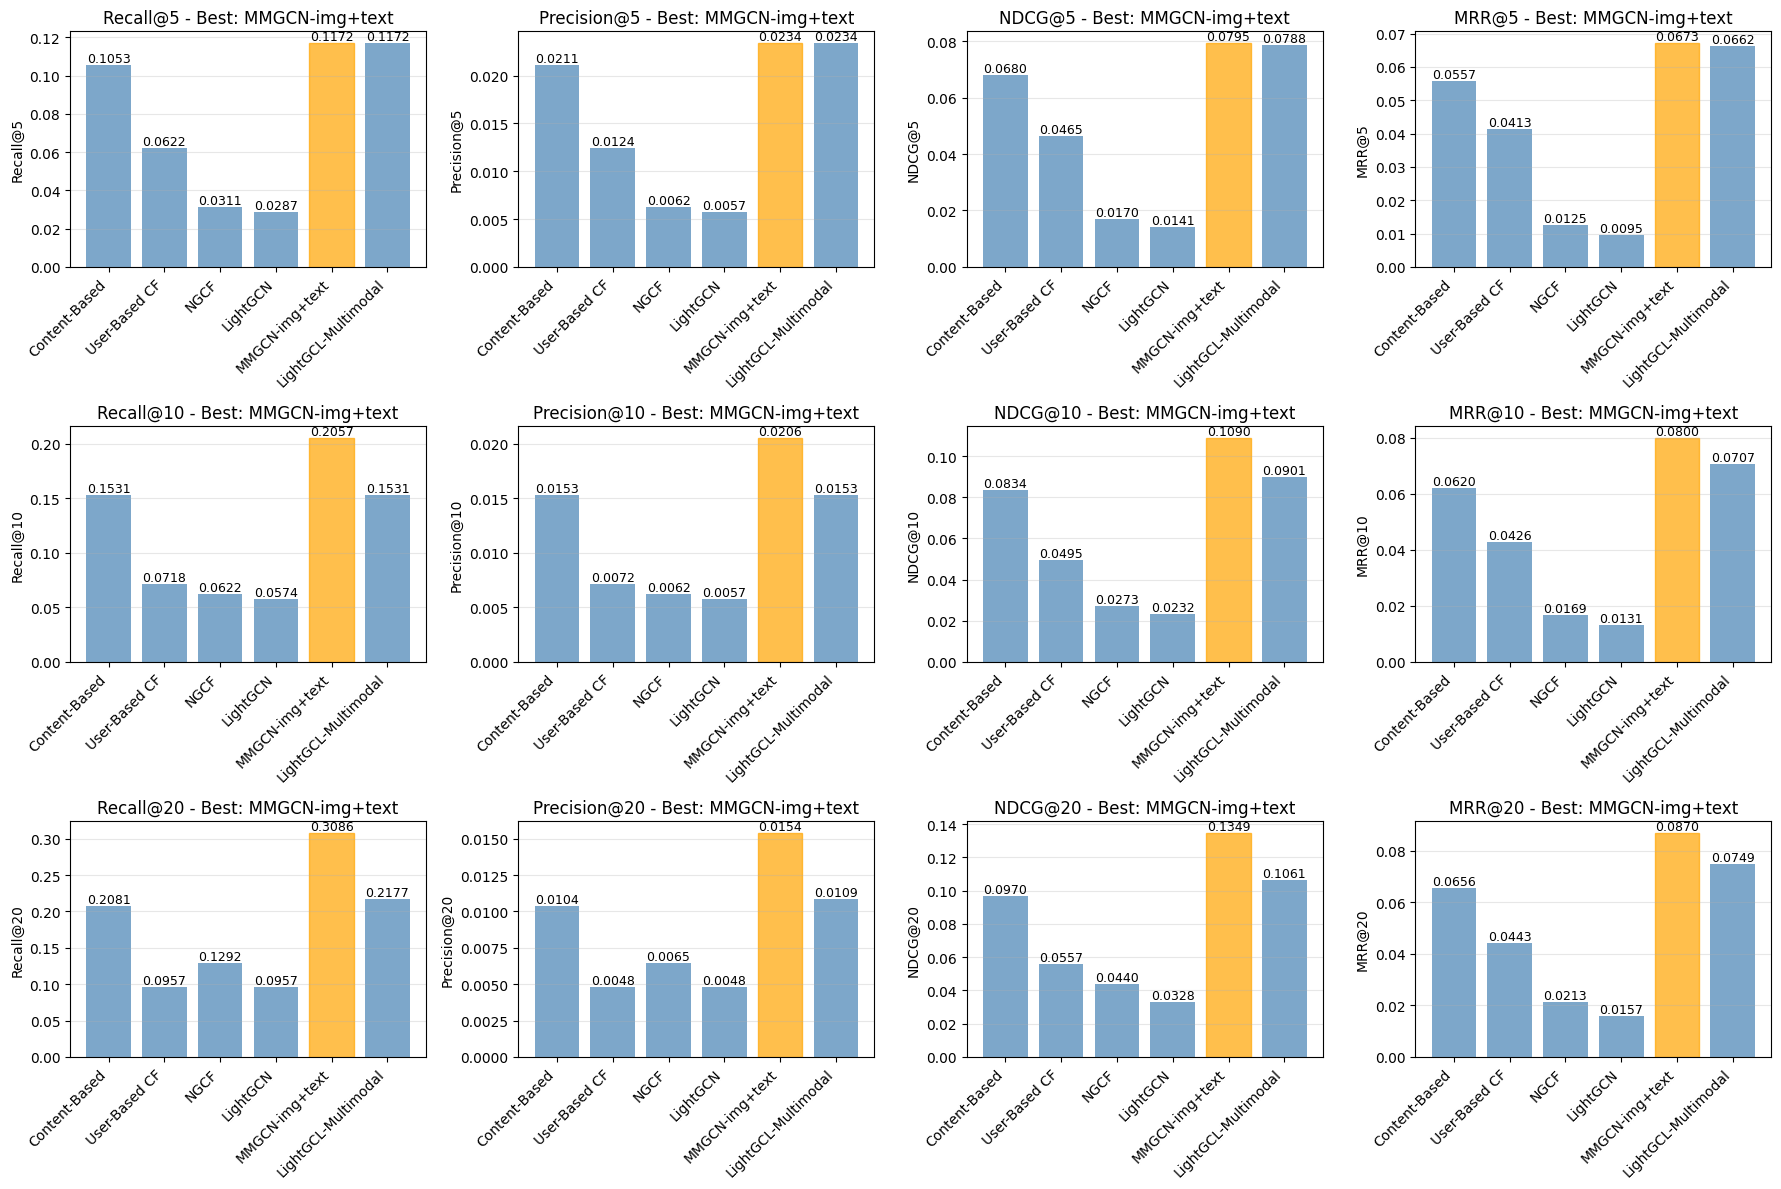

In [17]:
# ============================================================
# Visualize Results
# ============================================================
import matplotlib.pyplot as plt

def plot_model_comparison(results: Dict[str, Dict[str, float]], topks: List[int]):
    """Create bar plots comparing all models"""
    metrics = ["Recall", "Precision", "NDCG", "MRR"]
    model_names = list(results.keys())

    fig, axes = plt.subplots(len(topks), len(metrics), figsize=(18, 4*len(topks)))
    if len(topks) == 1:
        axes = axes.reshape(1, -1)

    for i, k in enumerate(topks):
        for j, metric in enumerate(metrics):
            ax = axes[i, j]
            metric_key = f"{metric}@{k}"
            values = [results[model].get(metric_key, 0) for model in model_names]

            bars = ax.bar(range(len(model_names)), values, color='steelblue', alpha=0.7)

            # Highlight best model
            best_idx = values.index(max(values))
            bars[best_idx].set_color('orange')

            ax.set_xticks(range(len(model_names)))
            ax.set_xticklabels(model_names, rotation=45, ha='right')
            ax.set_ylabel(f'{metric}@{k}')
            ax.set_title(f'{metric}@{k} - Best: {model_names[best_idx]}')
            ax.grid(axis='y', alpha=0.3)

            # Add value labels on bars
            for bar, val in zip(bars, values):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(cache_dir, 'model_comparison.png'), dpi=150, bbox_inches='tight')
    print(f"✓ Đã lưu biểu đồ so sánh tại {cache_dir}/model_comparison.png")
    plt.show()

# Create visualization
try:
    plot_model_comparison(results, TOPKS)
except Exception as e:
    print(f"Không thể tạo visualization: {e}")
    print("Bỏ qua bước này và tiếp tục...")

# Ablation: - description

In [18]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_description=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.10526315789473684, 'Recall@10': 0.15311004784688995, 'Recall@20': 0.20813397129186603, 'Precision@5': 0.02105263157894737, 'Precision@10': 0.015311004784688978, 'Precision@20': 0.010406698564593284, 'NDCG@5': 0.06797911105742906, 'NDCG@10': 0.08336954401860487, 'NDCG@20': 0.09703432799070183, 'MRR@5': 0.05566188197767144, 'MRR@10': 0.061959823801929055, 'MRR@20': 0.0655872063414059}

=== Training MMGCN (img+text) ===
[MMGCN] epoch 001 loss=0.6185
[MMGCN] epoch 005 loss=0.1617
[MMGCN] epoch 010 loss=0.0705
[MMGCN] epoch 015 loss=0.0434
[MMGCN] epoch 020 loss=0.0346
[MMGCN] epoch 025 loss=0.0266
[MMGCN] epoch 030 loss=0.0230
[MMGCN] epoch 035 loss=0.0194
[MMGCN] epoch 040 loss=0.0177
[MMGCN] epoch 045 loss=0.0156
[MMGCN] epoch 050 loss=0.0155
MMGCN-img+text: {'Re

In [19]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.1053      0.0211 0.0680 0.0557    0.1531       0.0153  0.0834 0.0620    0.2081       0.0104  0.0970 0.0656
     MMGCN-img+text   0.1220      0.0244 0.0823 0.0694    0.2057       0.0206  0.1092 0.0804    0.3038       0.0152  0.1338 0.0871
LightGCL-Multimodal   0.1172      0.0234 0.0742 0.0602    0.1699       0.0170  0.0908 0.0668    0.2249       0.0112  0.1044 0.0704

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.1220)
Precision@5    : MMGCN-img+text            (0.0244)
NDCG@5         : MMGCN-img+text            (0.0823)
MRR@5          : MMGCN-img+text            (0.0694)
Recall@10      : MMGCN-img+text            (0.2057)
Precision@10   : MMGCN-img+text            (0.0206)
NDCG@10        : MMGCN-img+text            (0.1092)
MRR@10         : MMGCN-img+tex

# Ablation: - material

In [20]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_material=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.09330143540669857, 'Recall@10': 0.16028708133971292, 'Recall@20': 0.24401913875598086, 'Precision@5': 0.018660287081339724, 'Precision@10': 0.016028708133971274, 'Precision@20': 0.01220095693779902, 'NDCG@5': 0.06403482322399018, 'NDCG@10': 0.08578597952722751, 'NDCG@20': 0.10690593079897327, 'MRR@5': 0.0543859649122807, 'MRR@10': 0.06341136933242195, 'MRR@20': 0.06918019215688345}

=== Training MMGCN (img+text) ===
[MMGCN] epoch 001 loss=0.6293
[MMGCN] epoch 005 loss=0.2213
[MMGCN] epoch 010 loss=0.1054
[MMGCN] epoch 015 loss=0.0603
[MMGCN] epoch 020 loss=0.0446
[MMGCN] epoch 025 loss=0.0339
[MMGCN] epoch 030 loss=0.0278
[MMGCN] epoch 035 loss=0.0233
[MMGCN] epoch 040 loss=0.0211
[MMGCN] epoch 045 loss=0.0185
[MMGCN] epoch 050 loss=0.0182
MMGCN-img+text: {'Rec

In [21]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.0933      0.0187 0.0640 0.0544    0.1603       0.0160  0.0858 0.0634    0.2440       0.0122  0.1069 0.0692
     MMGCN-img+text   0.1100      0.0220 0.0694 0.0562    0.2010       0.0201  0.0983 0.0679    0.3062       0.0153  0.1248 0.0751
LightGCL-Multimodal   0.0957      0.0191 0.0697 0.0613    0.1483       0.0148  0.0862 0.0678    0.1986       0.0099  0.0987 0.0711

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.1100)
Precision@5    : MMGCN-img+text            (0.0220)
NDCG@5         : LightGCL-Multimodal       (0.0697)
MRR@5          : LightGCL-Multimodal       (0.0613)
Recall@10      : MMGCN-img+text            (0.2010)
Precision@10   : MMGCN-img+text            (0.0201)
NDCG@10        : MMGCN-img+text            (0.0983)
MRR@10         : MMGCN-img+tex

# Ablation: - product_name

In [22]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_product_name=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.10526315789473684, 'Recall@10': 0.15311004784688995, 'Recall@20': 0.20813397129186603, 'Precision@5': 0.02105263157894737, 'Precision@10': 0.015311004784688978, 'Precision@20': 0.010406698564593284, 'NDCG@5': 0.06797911105742906, 'NDCG@10': 0.08336954401860487, 'NDCG@20': 0.09703432799070183, 'MRR@5': 0.05566188197767144, 'MRR@10': 0.061959823801929055, 'MRR@20': 0.0655872063414059}

=== Training MMGCN (img+text) ===
[MMGCN] epoch 001 loss=0.6185
[MMGCN] epoch 005 loss=0.1617
[MMGCN] epoch 010 loss=0.0705
[MMGCN] epoch 015 loss=0.0434
[MMGCN] epoch 020 loss=0.0346
[MMGCN] epoch 025 loss=0.0266
[MMGCN] epoch 030 loss=0.0230
[MMGCN] epoch 035 loss=0.0194
[MMGCN] epoch 040 loss=0.0177
[MMGCN] epoch 045 loss=0.0156
[MMGCN] epoch 050 loss=0.0155
MMGCN-img+text: {'Re

In [23]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.1053      0.0211 0.0680 0.0557    0.1531       0.0153  0.0834 0.0620    0.2081       0.0104  0.0970 0.0656
     MMGCN-img+text   0.1220      0.0244 0.0823 0.0694    0.2057       0.0206  0.1092 0.0804    0.3038       0.0152  0.1338 0.0871
LightGCL-Multimodal   0.1172      0.0234 0.0742 0.0602    0.1699       0.0170  0.0908 0.0668    0.2249       0.0112  0.1044 0.0704

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.1220)
Precision@5    : MMGCN-img+text            (0.0244)
NDCG@5         : MMGCN-img+text            (0.0823)
MRR@5          : MMGCN-img+text            (0.0694)
Recall@10      : MMGCN-img+text            (0.2057)
Precision@10   : MMGCN-img+text            (0.0206)
NDCG@10        : MMGCN-img+text            (0.1092)
MRR@10         : MMGCN-img+tex

# Ablation: - (material + description)

In [24]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_material=False, use_description=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.09330143540669857, 'Recall@10': 0.16028708133971292, 'Recall@20': 0.24401913875598086, 'Precision@5': 0.018660287081339724, 'Precision@10': 0.016028708133971274, 'Precision@20': 0.01220095693779902, 'NDCG@5': 0.06403482322399018, 'NDCG@10': 0.08578597952722751, 'NDCG@20': 0.10690593079897327, 'MRR@5': 0.0543859649122807, 'MRR@10': 0.06341136933242195, 'MRR@20': 0.06918019215688345}

=== Training MMGCN (img+text) ===
[MMGCN] epoch 001 loss=0.6293
[MMGCN] epoch 005 loss=0.2213
[MMGCN] epoch 010 loss=0.1054
[MMGCN] epoch 015 loss=0.0603
[MMGCN] epoch 020 loss=0.0446
[MMGCN] epoch 025 loss=0.0339
[MMGCN] epoch 030 loss=0.0278
[MMGCN] epoch 035 loss=0.0233
[MMGCN] epoch 040 loss=0.0211
[MMGCN] epoch 045 loss=0.0185
[MMGCN] epoch 050 loss=0.0182
MMGCN-img+text: {'Rec

In [25]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.0933      0.0187 0.0640 0.0544    0.1603       0.0160  0.0858 0.0634    0.2440       0.0122  0.1069 0.0692
     MMGCN-img+text   0.1100      0.0220 0.0694 0.0562    0.2010       0.0201  0.0983 0.0679    0.3062       0.0153  0.1248 0.0751
LightGCL-Multimodal   0.0957      0.0191 0.0697 0.0613    0.1483       0.0148  0.0862 0.0678    0.1986       0.0099  0.0987 0.0711

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.1100)
Precision@5    : MMGCN-img+text            (0.0220)
NDCG@5         : LightGCL-Multimodal       (0.0697)
MRR@5          : LightGCL-Multimodal       (0.0613)
Recall@10      : MMGCN-img+text            (0.2010)
Precision@10   : MMGCN-img+text            (0.0201)
NDCG@10        : MMGCN-img+text            (0.0983)
MRR@10         : MMGCN-img+tex

# Ablation: - (product_name + material)

In [26]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_material=False, use_product_name=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.09330143540669857, 'Recall@10': 0.16028708133971292, 'Recall@20': 0.24401913875598086, 'Precision@5': 0.018660287081339724, 'Precision@10': 0.016028708133971274, 'Precision@20': 0.01220095693779902, 'NDCG@5': 0.06403482322399018, 'NDCG@10': 0.08578597952722751, 'NDCG@20': 0.10690593079897327, 'MRR@5': 0.0543859649122807, 'MRR@10': 0.06341136933242195, 'MRR@20': 0.06918019215688345}

=== Training MMGCN (img+text) ===
[MMGCN] epoch 001 loss=0.6293
[MMGCN] epoch 005 loss=0.2213
[MMGCN] epoch 010 loss=0.1054
[MMGCN] epoch 015 loss=0.0603
[MMGCN] epoch 020 loss=0.0446
[MMGCN] epoch 025 loss=0.0339
[MMGCN] epoch 030 loss=0.0278
[MMGCN] epoch 035 loss=0.0233
[MMGCN] epoch 040 loss=0.0211
[MMGCN] epoch 045 loss=0.0185
[MMGCN] epoch 050 loss=0.0182
MMGCN-img+text: {'Rec

In [27]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.0933      0.0187 0.0640 0.0544    0.1603       0.0160  0.0858 0.0634    0.2440       0.0122  0.1069 0.0692
     MMGCN-img+text   0.1100      0.0220 0.0694 0.0562    0.2010       0.0201  0.0983 0.0679    0.3062       0.0153  0.1248 0.0751
LightGCL-Multimodal   0.0957      0.0191 0.0697 0.0613    0.1483       0.0148  0.0862 0.0678    0.1986       0.0099  0.0987 0.0711

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.1100)
Precision@5    : MMGCN-img+text            (0.0220)
NDCG@5         : LightGCL-Multimodal       (0.0697)
MRR@5          : LightGCL-Multimodal       (0.0613)
Recall@10      : MMGCN-img+text            (0.2010)
Precision@10   : MMGCN-img+text            (0.0201)
NDCG@10        : MMGCN-img+text            (0.0983)
MRR@10         : MMGCN-img+tex

# Ablation: - (product_name + description)

In [28]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_description=False, use_product_name=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.10526315789473684, 'Recall@10': 0.15311004784688995, 'Recall@20': 0.20813397129186603, 'Precision@5': 0.02105263157894737, 'Precision@10': 0.015311004784688978, 'Precision@20': 0.010406698564593284, 'NDCG@5': 0.06797911105742906, 'NDCG@10': 0.08336954401860487, 'NDCG@20': 0.09703432799070183, 'MRR@5': 0.05566188197767144, 'MRR@10': 0.061959823801929055, 'MRR@20': 0.0655872063414059}

=== Training MMGCN (img+text) ===
[MMGCN] epoch 001 loss=0.6185
[MMGCN] epoch 005 loss=0.1617
[MMGCN] epoch 010 loss=0.0705
[MMGCN] epoch 015 loss=0.0434
[MMGCN] epoch 020 loss=0.0346
[MMGCN] epoch 025 loss=0.0266
[MMGCN] epoch 030 loss=0.0230
[MMGCN] epoch 035 loss=0.0194
[MMGCN] epoch 040 loss=0.0177
[MMGCN] epoch 045 loss=0.0156
[MMGCN] epoch 050 loss=0.0155
MMGCN-img+text: {'Re

In [29]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.1053      0.0211 0.0680 0.0557    0.1531       0.0153  0.0834 0.0620    0.2081       0.0104  0.0970 0.0656
     MMGCN-img+text   0.1220      0.0244 0.0823 0.0694    0.2057       0.0206  0.1092 0.0804    0.3038       0.0152  0.1338 0.0871
LightGCL-Multimodal   0.1172      0.0234 0.0742 0.0602    0.1699       0.0170  0.0908 0.0668    0.2249       0.0112  0.1044 0.0704

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.1220)
Precision@5    : MMGCN-img+text            (0.0244)
NDCG@5         : MMGCN-img+text            (0.0823)
MRR@5          : MMGCN-img+text            (0.0694)
Recall@10      : MMGCN-img+text            (0.2057)
Precision@10   : MMGCN-img+text            (0.0206)
NDCG@10        : MMGCN-img+text            (0.1092)
MRR@10         : MMGCN-img+tex

# Ablation: - Text

In [30]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_description=False, use_product_name=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)
X_text_raw = np.zeros_like(X_text_raw)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.10526315789473684, 'Recall@10': 0.16507177033492823, 'Recall@20': 0.2511961722488038, 'Precision@5': 0.02105263157894737, 'Precision@10': 0.016507177033492804, 'Precision@20': 0.012559808612440167, 'NDCG@5': 0.06733289542018081, 'NDCG@10': 0.08616707674993009, 'NDCG@20': 0.10818767635465432, 'MRR@5': 0.05490430622009569, 'MRR@10': 0.06238323080428343, 'MRR@20': 0.0685528292332031}

=== Training MMGCN (img+text) ===


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_pca.py:648: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


[MMGCN] epoch 001 loss=0.6376
[MMGCN] epoch 005 loss=0.2238
[MMGCN] epoch 010 loss=0.1017
[MMGCN] epoch 015 loss=0.0585
[MMGCN] epoch 020 loss=0.0439
[MMGCN] epoch 025 loss=0.0334
[MMGCN] epoch 030 loss=0.0277
[MMGCN] epoch 035 loss=0.0231
[MMGCN] epoch 040 loss=0.0211
[MMGCN] epoch 045 loss=0.0185
[MMGCN] epoch 050 loss=0.0182
MMGCN-img+text: {'Recall@5': 0.11244019138755981, 'Recall@10': 0.20095693779904306, 'Recall@20': 0.31100478468899523, 'Precision@5': 0.02248803827751196, 'Precision@10': 0.020095693779904274, 'Precision@20': 0.015550239234449724, 'NDCG@5': 0.07319045312084921, 'NDCG@10': 0.10169739048432563, 'NDCG@20': 0.12921314626450914, 'MRR@5': 0.060366826156299826, 'MRR@10': 0.0720532391585023, 'MRR@20': 0.07942573382370366}

=== Training LightGCL-Multimodal ===
[LightGCL-MM] epoch 001 loss=1.4609
[LightGCL-MM] epoch 005 loss=1.1169
[LightGCL-MM] epoch 010 loss=0.8831
[LightGCL-MM] epoch 015 loss=0.7000
[LightGCL-MM] epoch 020 loss=0.6316
[LightGCL-MM] epoch 025 loss=0.6022

In [31]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.1053      0.0211 0.0673 0.0549    0.1651       0.0165  0.0862 0.0624    0.2512       0.0126  0.1082 0.0686
     MMGCN-img+text   0.1124      0.0225 0.0732 0.0604    0.2010       0.0201  0.1017 0.0721    0.3110       0.0156  0.1292 0.0794
LightGCL-Multimodal   0.0981      0.0196 0.0731 0.0650    0.1435       0.0144  0.0876 0.0709    0.2105       0.0105  0.1043 0.0754

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.1124)
Precision@5    : MMGCN-img+text            (0.0225)
NDCG@5         : MMGCN-img+text            (0.0732)
MRR@5          : LightGCL-Multimodal       (0.0650)
Recall@10      : MMGCN-img+text            (0.2010)
Precision@10   : MMGCN-img+text            (0.0201)
NDCG@10        : MMGCN-img+text            (0.1017)
MRR@10         : MMGCN-img+tex

# Ablation: - Img

In [32]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m, use_description=False, use_product_name=False)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)
X_img_raw = np.zeros_like(X_img_raw)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

# 1) Content-Based Filtering
print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)
cb_model = train_content_based(
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,  # Equal weight for image and text
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based"] = res
print("Content-Based:", res)

# 2) MMGCN (img+text)
print("\n=== Training MMGCN (img+text) ===")
mmgcn_model = train_mmgcn(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,   # use PCA dims for efficiency
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, TOPKS)
results["MMGCN-img+text"] = res
print("MMGCN-img+text:", res)

# 3) LightGCL-Multimodal
print("\n=== Training LightGCL-Multimodal ===")
lgcl_model = train_lightgcl_multimodal(
    R_train=R_train,
    train_pos=train_pos,
    # X_img=X_img_pca,
    # X_txt=X_text_pca,
    X_img=X_img_raw,
    X_txt=X_text_raw,
    num_users=num_users,
    num_items=num_items,
)
lgcl_score_fn = make_gnn_score_fn(lambda: lgcl_model.forward_local(), num_items)  # or lgcl_model.forward_local()
res = evaluate_from_score_fn(lgcl_score_fn, test_df, train_pos, num_items, TOPKS)
results["LightGCL-Multimodal"] = res
print("LightGCL-Multimodal:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
[ContentBased] Building user profiles with alpha=0.50
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based: {'Recall@5': 0.0645933014354067, 'Recall@10': 0.12440191387559808, 'Recall@20': 0.16028708133971292, 'Precision@5': 0.012918660287081345, 'Precision@10': 0.012440191387559803, 'Precision@20': 0.008014354066985637, 'NDCG@5': 0.03933624112415079, 'NDCG@10': 0.0589706538512448, 'NDCG@20': 0.06794753402900211, 'MRR@5': 0.03110047846889952, 'MRR@10': 0.03938634464950253, 'MRR@20': 0.041804907470505095}

=== Training MMGCN (img+text) ===


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_pca.py:648: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


[MMGCN] epoch 001 loss=0.6658
[MMGCN] epoch 005 loss=0.3305
[MMGCN] epoch 010 loss=0.1812
[MMGCN] epoch 015 loss=0.1211
[MMGCN] epoch 020 loss=0.0953
[MMGCN] epoch 025 loss=0.0811
[MMGCN] epoch 030 loss=0.0732
[MMGCN] epoch 035 loss=0.0669
[MMGCN] epoch 040 loss=0.0631
[MMGCN] epoch 045 loss=0.0604
[MMGCN] epoch 050 loss=0.0582
MMGCN-img+text: {'Recall@5': 0.06698564593301436, 'Recall@10': 0.1339712918660287, 'Recall@20': 0.20574162679425836, 'Precision@5': 0.013397129186602876, 'Precision@10': 0.013397129186602862, 'Precision@20': 0.010287081339712902, 'NDCG@5': 0.04177112763325604, 'NDCG@10': 0.06362313450391073, 'NDCG@20': 0.0817687696221062, 'MRR@5': 0.033572567783094094, 'MRR@10': 0.04270809599756965, 'MRR@20': 0.04768243133875583}

=== Training LightGCL-Multimodal ===
[LightGCL-MM] epoch 001 loss=1.3076
[LightGCL-MM] epoch 005 loss=1.1510
[LightGCL-MM] epoch 010 loss=1.1148
[LightGCL-MM] epoch 015 loss=1.0897
[LightGCL-MM] epoch 020 loss=1.0529
[LightGCL-MM] epoch 025 loss=1.0109

In [33]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
              Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
      Content-Based   0.0646      0.0129 0.0393 0.0311    0.1244       0.0124  0.0590 0.0394    0.1603       0.0080  0.0679 0.0418
     MMGCN-img+text   0.0670      0.0134 0.0418 0.0336    0.1340       0.0134  0.0636 0.0427    0.2057       0.0103  0.0818 0.0477
LightGCL-Multimodal   0.0263      0.0053 0.0162 0.0128    0.0526       0.0053  0.0246 0.0162    0.0885       0.0044  0.0336 0.0187

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : MMGCN-img+text            (0.0670)
Precision@5    : MMGCN-img+text            (0.0134)
NDCG@5         : MMGCN-img+text            (0.0418)
MRR@5          : MMGCN-img+text            (0.0336)
Recall@10      : MMGCN-img+text            (0.1340)
Precision@10   : MMGCN-img+text            (0.0134)
NDCG@10        : MMGCN-img+text            (0.0636)
MRR@10         : MMGCN-img+tex

# Content-based on other similarity

In [34]:
from typing import Dict, List, Tuple, Optional
import numpy as np

class ContentBasedRecommenderOtherSim:
    """
    Content-based recommendation using item features (text + image embeddings).

    Supports similarity metrics:
      - "dot": dot product
      - "euclidean": negative Euclidean distance
      - "mahalanobis": negative Mahalanobis distance via PCA whitening
    """
    def __init__(
        self,
        X_img: np.ndarray,
        X_txt: np.ndarray,
        train_pos: Dict[int, set],
        num_users: int,
        num_items: int,
        alpha: float = 0.5,
        metric: str = "dot",
        cb_common_dim: Optional[int] = None,   # for making X_img and X_txt same dim if needed
        mahalanobis_whiten_dim: int = 128,     # used only if metric="mahalanobis"
        seed: int = 42,
    ):
        self.num_users = num_users
        self.num_items = num_items
        self.alpha = alpha
        self.metric = metric.lower()

        # --- Ensure image/text have the same dim for fusion-by-addition ---
        # Your current fusion is: alpha*X_img + (1-alpha)*X_txt, which requires same dims.
        if X_img.shape[1] != X_txt.shape[1]:
            if cb_common_dim is None:
                # pick a safe common dim automatically
                cb_common_dim = min(256, X_img.shape[0], X_img.shape[1], X_txt.shape[1])
            from sklearn.decomposition import PCA
            p_img = PCA(n_components=min(cb_common_dim, X_img.shape[0], X_img.shape[1]), random_state=seed)
            p_txt = PCA(n_components=min(cb_common_dim, X_txt.shape[0], X_txt.shape[1]), random_state=seed)
            X_img = p_img.fit_transform(X_img).astype(np.float32)
            X_txt = p_txt.fit_transform(X_txt).astype(np.float32)

        # --- Preprocess depending on metric ---
        if self.metric in ("dot", "euclidean"):
            # For dot product and Euclidean, using standardized scaling often helps stability
            # but is optional. We'll keep it minimal:
            self.X_img = X_img.astype(np.float32)
            self.X_txt = X_txt.astype(np.float32)

            # Fuse features (same dim now)
            self.X_items = (alpha * self.X_img + (1 - alpha) * self.X_txt).astype(np.float32)

        elif self.metric == "mahalanobis":
            # Mahalanobis via whitening: PCA(whiten=True) then Euclidean.
            # Fit whitening on fused item features.
            from sklearn.decomposition import PCA

            fused = (alpha * X_img + (1 - alpha) * X_txt).astype(np.float32)

            # n_components must be <= min(n_samples, n_features)
            max_dim = min(fused.shape[0], fused.shape[1])
            d = min(mahalanobis_whiten_dim, max_dim)

            self._pca_whiten = PCA(n_components=d, whiten=True, random_state=seed)
            self.X_items = self._pca_whiten.fit_transform(fused).astype(np.float32)

        else:
            raise ValueError(f"Unknown metric='{metric}'. Use one of: dot, euclidean, mahalanobis")

        # Build user profiles (mean of interacted items in the same feature space)
        self.user_profiles = self._build_user_profiles(train_pos)

    def _build_user_profiles(self, train_pos: Dict[int, set]) -> np.ndarray:
        user_profiles = np.zeros((self.num_users, self.X_items.shape[1]), dtype=np.float32)
        for user_id, item_set in train_pos.items():
            if item_set:
                item_list = list(item_set)
                user_profiles[int(user_id)] = np.mean(self.X_items[item_list], axis=0)
        return user_profiles

    def score_users_items(self, u_batch: np.ndarray) -> np.ndarray:
        U = self.user_profiles[u_batch.astype(np.int64)]  # [B, D]
        V = self.X_items                               # [I, D]

        if self.metric == "dot":
            # score = u^T v
            return (U @ V.T).astype(np.float32)

        # Euclidean or Mahalanobis (in whitened space) => negative distance
        # Compute squared distances efficiently:
        # ||u-v||^2 = ||u||^2 + ||v||^2 - 2u·v
        u2 = np.sum(U * U, axis=1, keepdims=True)      # [B,1]
        v2 = np.sum(V * V, axis=1, keepdims=True).T    # [1,I]
        dist2 = np.maximum(u2 + v2 - 2.0 * (U @ V.T), 0.0)
        dist = np.sqrt(dist2 + 1e-12)
        scores = -dist  # higher score = closer
        return scores.astype(np.float32)


def train_content_based_other_sim(
    X_img: np.ndarray,
    X_txt: np.ndarray,
    train_pos: Dict[int, set],
    num_users: int,
    num_items: int,
    alpha: float = 0.5,
    metric: str = "dot",
    cb_common_dim: Optional[int] = None,
    mahalanobis_whiten_dim: int = 128,
    seed: int = 42,
) -> ContentBasedRecommenderOtherSim:
    print(f"[ContentBased] Building user profiles with alpha={alpha:.2f}, metric={metric}")
    model = ContentBasedRecommenderOtherSim(
        X_img=X_img,
        X_txt=X_txt,
        train_pos=train_pos,
        num_users=num_users,
        num_items=num_items,
        alpha=alpha,
        metric=metric,
        cb_common_dim=cb_common_dim,
        mahalanobis_whiten_dim=mahalanobis_whiten_dim,
        seed=seed,
    )
    print(f"[ContentBased] User profiles built. Shape: {model.user_profiles.shape}")
    return model


In [35]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image), then PCA ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# print("PCA compression...")
# X_text_pca, pca_t = fit_pca(X_text_raw, PCA_TEXT_DIM, seed=SEED)
# X_img_pca,  pca_i = fit_pca(X_img_raw,  PCA_IMG_DIM,  seed=SEED)

# ---- Train + evaluate each model ----
results = {}

print("\n=== Training Content-Based Filtering ===")
print("PCA image embeddings to match text dimension...")
# Max = 349, so reduce to 300 for all.
X_img_cb, pca_img_300 = fit_pca(X_img_raw, 300, seed=SEED)
X_txt_cb, pca_txt_300 = fit_pca(X_text_raw, 300, seed=SEED)

# "dot", "euclidean"
# Content-based mahalanobis
print("Mahalanobis similarity:")
cb_model = train_content_based_other_sim(
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,
    metric="mahalanobis",
    cb_common_dim=None,
    mahalanobis_whiten_dim=128,
    seed=SEED,
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based-Mahalanobis"] = res
print("Content-Based-Mahalanobis:", res)

# Content-based dot
print("Dot similarity:")
cb_model = train_content_based_other_sim(
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,
    metric="dot",
    cb_common_dim=None,
    seed=SEED,
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based-Dot"] = res
print("Content-Based-Dot:", res)

# Content-based mahalanobis
print("Euclidean similarity:")
cb_model = train_content_based_other_sim(
    X_img=X_img_cb,
    X_txt=X_txt_cb,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    alpha=0.5,
    metric="euclidean",
    cb_common_dim=None,
    mahalanobis_whiten_dim=128,
    seed=SEED,
)
cb_score_fn = lambda u_batch: cb_model.score_users_items(u_batch)
res = evaluate_from_score_fn(cb_score_fn, test_df, train_pos, num_items, TOPKS)
results["Content-Based-Euclidean"] = res
print("Content-Based-Euclidean:", res)


print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]


=== Training Content-Based Filtering ===
PCA image embeddings to match text dimension...
Mahalanobis similarity:
[ContentBased] Building user profiles with alpha=0.50, metric=mahalanobis
[ContentBased] User profiles built. Shape: (3829, 128)
Content-Based-Mahalanobis: {'Recall@5': 0.050239234449760764, 'Recall@10': 0.07177033492822966, 'Recall@20': 0.12440191387559808, 'Precision@5': 0.010047846889952156, 'Precision@10': 0.007177033492822969, 'Precision@20': 0.006220095693779902, 'NDCG@5': 0.036622085067522146, 'NDCG@10': 0.043554165008686904, 'NDCG@20': 0.056609350178259896, 'MRR@5': 0.03209728867623604, 'MRR@10': 0.03494436849700007, 'MRR@20': 0.038392310174588294}
Dot similarity:
[ContentBased] Building user profiles with alpha=0.50, metric=dot
[ContentBased] User profiles built. Shape: (3829, 300)
Content-Based-Dot: {'Recall@5': 0.09330143540669857, 'Recall@10': 0.16028708133971292, 'Recall@20': 0.22248803827751196, 'Precision@5': 0.018660287081339724, 'Precision@10': 0.0160287081

In [36]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
                    Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
Content-Based-Mahalanobis   0.0502      0.0100 0.0366 0.0321    0.0718       0.0072  0.0436 0.0349    0.1244       0.0062  0.0566 0.0384
        Content-Based-Dot   0.0933      0.0187 0.0613 0.0508    0.1603       0.0160  0.0827 0.0595    0.2225       0.0111  0.0984 0.0638
  Content-Based-Euclidean   0.0981      0.0196 0.0601 0.0477    0.1722       0.0172  0.0832 0.0568    0.2488       0.0124  0.1025 0.0620

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : Content-Based-Euclidean   (0.0981)
Precision@5    : Content-Based-Euclidean   (0.0196)
NDCG@5         : Content-Based-Dot         (0.0613)
MRR@5          : Content-Based-Dot         (0.0508)
Recall@10      : Content-Based-Euclidean   (0.1722)
Precision@10   : Content-Based-Euclidean   (0.0172)
NDCG@10        : Content-Based-Euclidean   (0.0832)
MRR@10

# User-based on other similarity

In [37]:
import scipy.sparse as sp
from tqdm.auto import tqdm

class UserBasedCFOtherSim:
    """
    User-based CF with selectable similarity metrics:
      - "dot": dot product similarity
      - "euclidean": negative Euclidean distance
      - "mahalanobis": negative distance after PCA whitening (Mahalanobis)
    """
    def __init__(
        self,
        R_train: sp.csr_matrix,
        train_pos: Dict[int, set],
        num_users: int,
        num_items: int,
        k_neighbors: int = 50,
        metric: str = "dot",
        mahalanobis_whiten_dim: int = 128,
        seed: int = 42,
    ):
        self.num_users = num_users
        self.num_items = num_items
        self.k_neighbors = k_neighbors
        self.train_pos = train_pos
        self.metric = metric.lower()

        # Prepare user representations
        if self.metric in ("dot", "euclidean"):
            # Convert sparse user vectors to dense only when needed in batches.
            self.R = R_train.tocsr()
            self._pca_whiten = None

        elif self.metric == "mahalanobis":
            # For Mahalanobis: whiten user vectors then use Euclidean in whitened space.
            from sklearn.decomposition import PCA

            X = R_train.toarray().astype(np.float32)  # [U, I]
            max_dim = min(X.shape[0], X.shape[1])
            d = min(mahalanobis_whiten_dim, max_dim)

            self._pca_whiten = PCA(n_components=d, whiten=True, random_state=seed)
            self.Xw = self._pca_whiten.fit_transform(X).astype(np.float32)  # [U, d]
        else:
            raise ValueError(f"Unknown metric='{metric}'. Use: dot, euclidean, mahalanobis")

        print(f"[UserBasedCF] Computing user-user similarities (k={k_neighbors}, metric={self.metric})...")
        self.user_similarities = self._compute_user_similarities()

    def _topk_from_scores(self, scores: np.ndarray, user_id: int) -> List[Tuple[int, float]]:
        scores[user_id] = -np.inf
        k = min(self.k_neighbors, self.num_users - 1)
        idx = np.argpartition(scores, -k)[-k:]
        idx = idx[np.argsort(-scores[idx])]
        return [(int(j), float(scores[j])) for j in idx if np.isfinite(scores[j]) and scores[j] > 0]

    def _compute_user_similarities(self) -> Dict[int, List[Tuple[int, float]]]:
        similarities: Dict[int, List[Tuple[int, float]]] = {}

        batch_size = 256
        for start in tqdm(range(0, self.num_users, batch_size), desc="Computing similarities"):
            end = min(start + batch_size, self.num_users)

            if self.metric == "dot":
                # dot similarity on sparse: (B x I) @ (I x U) => (B x U)
                batch_sim = (self.R[start:end] @ self.R.T).toarray().astype(np.float32)

            elif self.metric == "euclidean":
                # Negative Euclidean distance: need dense batches
                Xb = self.R[start:end].toarray().astype(np.float32)  # [B, I]
                X  = self.R.toarray().astype(np.float32)             # [U, I] (costly if U large)
                # Efficient distance via ||a-b||^2 = ||a||^2 + ||b||^2 - 2a·b
                b2 = np.sum(Xb * Xb, axis=1, keepdims=True)
                x2 = np.sum(X * X, axis=1, keepdims=True).T
                dist2 = np.maximum(b2 + x2 - 2.0 * (Xb @ X.T), 0.0)
                batch_sim = -np.sqrt(dist2 + 1e-12)

            else:  # mahalanobis
                Xb = self.Xw[start:end]          # [B, d]
                X  = self.Xw                      # [U, d]
                b2 = np.sum(Xb * Xb, axis=1, keepdims=True)
                x2 = np.sum(X * X, axis=1, keepdims=True).T
                dist2 = np.maximum(b2 + x2 - 2.0 * (Xb @ X.T), 0.0)
                batch_sim = -np.sqrt(dist2 + 1e-12)

            for i, user_id in enumerate(range(start, end)):
                sims = batch_sim[i].copy()
                # Keep top-k positive similarities
                similarities[user_id] = self._topk_from_scores(sims, user_id)

        return similarities

    def score_users_items(self, u_batch: np.ndarray) -> np.ndarray:
        scores = np.zeros((len(u_batch), self.num_items), dtype=np.float32)
        for i, u in enumerate(u_batch):
            u = int(u)
            neighbors = self.user_similarities.get(u, [])
            for v, sim in neighbors:
                for item_id in self.train_pos.get(v, set()):
                    scores[i, item_id] += sim
        return scores


def train_user_based_cf_other_sim(
    R_train: sp.csr_matrix,
    train_pos: Dict[int, set],
    num_users: int,
    num_items: int,
    k_neighbors: int = 50,
    metric: str = "dot",
    mahalanobis_whiten_dim: int = 128,
    seed: int = 42,
) -> UserBasedCFOtherSim:
    print(f"[UserBasedCF] Building model (k_neighbors={k_neighbors}, metric={metric})")
    model = UserBasedCFOtherSim(
        R_train=R_train,
        train_pos=train_pos,
        num_users=num_users,
        num_items=num_items,
        k_neighbors=k_neighbors,
        metric=metric,
        mahalanobis_whiten_dim=mahalanobis_whiten_dim,
        seed=seed,
    )
    print("[UserBasedCF] Model built successfully")
    return model


In [38]:
set_seed(SEED)
print(f"Using DEVICE={DEVICE}")
print("Loading data...")
df_reviews, df_products = load_data(REVIEWS_CSV, PRODUCTS_CSV)

print("Mapping IDs...")
df_reviews_m, df_products_m, reviewer_to_user, product_to_item, _ = build_id_maps(df_reviews, df_products)
num_users = len(reviewer_to_user)
num_items = len(product_to_item)
print(f"Users: {num_users}  Items: {num_items}  Reviews(after filter): {len(df_reviews_m)}")

print("Building implicit positives...")
df_pos = build_implicit_positives(df_reviews_m, POS_THRESHOLD)
print(f"Positive interactions: {len(df_pos)}")

print("Splitting (leave-one-out)...")
train_df, test_df = leave_one_out_split(df_pos, seed=SEED)
train_pos = build_train_pos_dict(train_df)
print(f"Train positives: {len(train_df)}  Test: {len(test_df)}  Users in test: {test_df.user_id.nunique()}")

print("Building train CSR...")
R_train = build_interaction_csr(train_df, num_users, num_items)

# ---- Build modalities (text + image) ----
cache_dir = "./cache_multimodal"
os.makedirs(cache_dir, exist_ok=True)

print("Encoding text...")
corpus = build_item_text_corpus(df_products_m)
X_text_raw = encode_text_sentence_transformer(corpus, batch_size=64)

print("Encoding images from local folder...")
X_img_raw = encode_images_openclip(df_products_m, batch_size=64)

# ---- Train + evaluate each user-based model ----
results = {}

print("\n=== Training User-Based CF ===")
print("Mahalanobis similarity:")
ubcf_model = train_user_based_cf_other_sim(
    R_train=R_train,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    k_neighbors=50,
    metric="mahalanobis",
    mahalanobis_whiten_dim=128,
    seed=SEED,
)

ubcf_score_fn = lambda u_batch: ubcf_model.score_users_items(u_batch)
res = evaluate_from_score_fn(ubcf_score_fn, test_df, train_pos, num_items, TOPKS)
results["User-Based-CF-Mahalanobis"] = res
print("User-Based CF Mahalanobis:", res)

print("Dot similarity:")
ubcf_model = train_user_based_cf_other_sim(
    R_train=R_train,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    k_neighbors=50,
    metric="dot",
    seed=SEED,
)

ubcf_score_fn = lambda u_batch: ubcf_model.score_users_items(u_batch)
res = evaluate_from_score_fn(ubcf_score_fn, test_df, train_pos, num_items, TOPKS)
results["User-Based-CF-Dot"] = res
print("User-Based CF Dot:", res)


print("Euclidean similarity:")
ubcf_model = train_user_based_cf_other_sim(
    R_train=R_train,
    train_pos=train_pos,
    num_users=num_users,
    num_items=num_items,
    k_neighbors=50,
    metric="euclidean",
    seed=SEED,
)

ubcf_score_fn = lambda u_batch: ubcf_model.score_users_items(u_batch)
res = evaluate_from_score_fn(ubcf_score_fn, test_df, train_pos, num_items, TOPKS)
results["User-Based-CF-Euclidean"] = res
print("User-Based CF Euclidean:", res)

print("\n=== Summary ===")
print(json.dumps(results, indent=2))

Using DEVICE=cuda
Loading data...
Mapping IDs...
Users: 3829  Items: 349  Reviews(after filter): 4391
Building implicit positives...
Positive interactions: 4358
Splitting (leave-one-out)...
Train positives: 3940  Test: 418  Users in test: 418
Building train CSR...
Encoding text...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding images from local folder...


/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


[OpenCLIP] Encoding images:   0%|          | 0/349 [00:00<?, ?it/s]

...

[UserBasedCF] Model built successfully
User-Based CF Mahalanobis: {'Recall@5': 0.007177033492822967, 'Recall@10': 0.014354066985645933, 'Recall@20': 0.03827751196172249, 'Precision@5': 0.0014354066985645935, 'Precision@10': 0.0014354066985645933, 'Precision@20': 0.0019138755980861247, 'NDCG@5': 0.007177033492822967, 'NDCG@10': 0.009314819448376805, 'NDCG@20': 0.015488473974009834, 'MRR@5': 0.007177033492822967, 'MRR@10': 0.007954545454545455, 'MRR@20': 0.009710566651513515}
Dot similarity:
[UserBasedCF] Building model (k_neighbors=50, metric=dot)
[UserBasedCF] Computing user-user similarities (k=50, metric=dot)...


Computing similarities:   0%|          | 0/15 [00:00<?, ?it/s]

[UserBasedCF] Model built successfully
User-Based CF Dot: {'Recall@5': 0.05741626794258373, 'Recall@10': 0.07894736842105263, 'Recall@20': 0.09808612440191387, 'Precision@5': 0.01148325358851675, 'Precision@10': 0.007894736842105267, 'Precision@20': 0.004904306220095696, 'NDCG@5': 0.041510320119899545, 'NDCG@10': 0.04834515200112412, 'NDCG@20': 0.05326746062198918, 'MRR@5': 0.03624401913875598, 'MRR@10': 0.038984772537404115, 'MRR@20': 0.040375354310761}
Euclidean similarity:
[UserBasedCF] Building model (k_neighbors=50, metric=euclidean)
[UserBasedCF] Computing user-user similarities (k=50, metric=euclidean)...


Computing similarities:   0%|          | 0/15 [00:00<?, ?it/s]

[UserBasedCF] Model built successfully
User-Based CF Euclidean: {'Recall@5': 0.007177033492822967, 'Recall@10': 0.014354066985645933, 'Recall@20': 0.03827751196172249, 'Precision@5': 0.0014354066985645935, 'Precision@10': 0.0014354066985645933, 'Precision@20': 0.0019138755980861247, 'NDCG@5': 0.007177033492822967, 'NDCG@10': 0.009314819448376805, 'NDCG@20': 0.015488473974009834, 'MRR@5': 0.007177033492822967, 'MRR@10': 0.007954545454545455, 'MRR@20': 0.009710566651513515}

=== Summary ===
{
  "User-Based-CF-Mahalanobis": {
    "Recall@5": 0.007177033492822967,
    "Recall@10": 0.014354066985645933,
    "Recall@20": 0.03827751196172249,
    "Precision@5": 0.0014354066985645935,
    "Precision@10": 0.0014354066985645933,
    "Precision@20": 0.0019138755980861247,
    "NDCG@5": 0.007177033492822967,
    "NDCG@10": 0.009314819448376805,
    "NDCG@20": 0.015488473974009834,
    "MRR@5": 0.007177033492822967,
    "MRR@10": 0.007954545454545455,
    "MRR@20": 0.009710566651513515
  },
  "User

In [39]:
# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
                    Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
User-Based-CF-Mahalanobis   0.0072      0.0014 0.0072 0.0072    0.0144       0.0014  0.0093 0.0080    0.0383       0.0019  0.0155 0.0097
        User-Based-CF-Dot   0.0574      0.0115 0.0415 0.0362    0.0789       0.0079  0.0483 0.0390    0.0981       0.0049  0.0533 0.0404
  User-Based-CF-Euclidean   0.0072      0.0014 0.0072 0.0072    0.0144       0.0014  0.0093 0.0080    0.0383       0.0019  0.0155 0.0097

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : User-Based-CF-Dot         (0.0574)
Precision@5    : User-Based-CF-Dot         (0.0115)
NDCG@5         : User-Based-CF-Dot         (0.0415)
MRR@5          : User-Based-CF-Dot         (0.0362)
Recall@10      : User-Based-CF-Dot         (0.0789)
Precision@10   : User-Based-CF-Dot         (0.0079)
NDCG@10        : User-Based-CF-Dot         (0.0483)
MRR@10

# Text embeddings

In [40]:
import os, json, gc
import numpy as np
import torch

# -----------------------------
# Text model list (required)
# -----------------------------
TEXT_MODELS = [
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "sentence-transformers/stsb-xlm-r-multilingual",
    "sentence-transformers/LaBSE",
    "sentence-transformers/use-cmlm-multilingual",
    "sentence-transformers/all-mpnet-base-v2",
]

# A "MiniLM-like" common dim, but must be <= num_items (349 here).
# 256 is a good safe choice for repeated runs on T4.
COMMON_TEXT_DIM = 256

# -----------------------------
# Helper: encode with a chosen SentenceTransformer model
# -----------------------------
def encode_text_sentence_transformer_model(texts, model_name: str, batch_size: int = 32) -> np.ndarray:
    """
    Encode texts using a specified SentenceTransformer model.
    T4-safe settings: moderate batch_size, GPU if available.
    """
    try:
        from sentence_transformers import SentenceTransformer
    except Exception as e:
        raise RuntimeError("Please install sentence-transformers (pip install sentence-transformers)") from e

    model = SentenceTransformer(model_name)
    if DEVICE == "cuda":
        model = model.to(DEVICE)

    # Safer for VRAM: smaller batch for larger models (mpnet/xlm-r/labse)
    embs = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=False,
    )
    return embs.astype(np.float32)

# -----------------------------
# Helper: PCA compress to a fixed dim (optional but recommended)
# -----------------------------
def pca_to_common_dim(X: np.ndarray, target_dim: int, seed: int = 42) -> np.ndarray:
    """
    PCA to a target dim that must be <= min(n_samples, n_features).
    Returns float32.
    """
    target_dim = int(min(target_dim, X.shape[0], X.shape[1]))
    Z, _ = fit_pca(X, out_dim=target_dim, seed=seed)
    return Z.astype(np.float32)

# -----------------------------
# Main experiment loop
# -----------------------------
def run_mmgcn_text_model_sweep(
    df_products_m,
    R_train,
    train_pos,
    test_df,
    X_img_raw,
    num_users: int,
    num_items: int,
    topks,
    text_models,
    cache_dir="./cache_multimodal_text_models",
    common_text_dim=256,
) -> dict:
    os.makedirs(cache_dir, exist_ok=True)

    # Build corpus once
    print("Building text corpus once...")
    corpus = build_item_text_corpus(df_products_m)

    all_results = {}

    for model_name in text_models:
        print("\n" + "="*90)
        print(f"[TEXT MODEL] {model_name}")

        # ---- 1) Load/compute text embeddings ----
        safe_name = model_name.replace("/", "__")
        emb_path = os.path.join(cache_dir, f"text_{safe_name}.npy")
        pca_path = os.path.join(cache_dir, f"text_{safe_name}_pca{common_text_dim}.npy")

        if os.path.exists(pca_path):
            X_txt = np.load(pca_path)
            print(f"Loaded cached PCA text embeddings: {X_txt.shape}")
        else:
            if os.path.exists(emb_path):
                X_txt_raw = np.load(emb_path)
                print(f"Loaded cached raw text embeddings: {X_txt_raw.shape}")
            else:
                # T4-safe batch sizing
                # Bigger models often need smaller batches
                bs = 16 if ("xlm-r" in model_name.lower() or "mpnet" in model_name.lower() or "labse" in model_name.lower()) else 32
                print(f"Encoding text (batch_size={bs})...")
                X_txt_raw = encode_text_sentence_transformer_model(corpus, model_name=model_name, batch_size=bs)
                np.save(emb_path, X_txt_raw)

            # ---- 2) PCA to a common dimension (recommended for repeated training) ----
            # Note: ensures similar dimensionality across models and keeps training stable/fast.
            target_dim = min(common_text_dim, num_items, X_txt_raw.shape[1])
            print(f"PCA text to target_dim={target_dim} (<= num_items={num_items})...")
            X_txt = pca_to_common_dim(X_txt_raw, target_dim=target_dim, seed=SEED)
            np.save(pca_path, X_txt)

        # ---- 3) Train MMGCN using the same pipeline ----
        print("\n=== Training MMGCN (img + text) ===")
        mmgcn_model = train_mmgcn(
            R_train=R_train,
            train_pos=train_pos,
            X_img=X_img_raw,      # keep images fixed
            X_txt=X_txt,          # varying text model (PCA-compressed)
            num_users=num_users,
            num_items=num_items,
        )

        # ---- 4) Evaluate ----
        mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
        res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, topks)
        all_results[model_name] = res

        print("MMGCN result:", res)

        # ---- 5) Cleanup between runs (T4 safety) ----
        del mmgcn_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return all_results

# -----------------------------
# Run the sweep (after you already computed X_img_raw)
# -----------------------------
results_text_sweep = run_mmgcn_text_model_sweep(
    df_products_m=df_products_m,
    R_train=R_train,
    train_pos=train_pos,
    test_df=test_df,
    X_img_raw=X_img_raw,
    num_users=num_users,
    num_items=num_items,
    topks=TOPKS,
    text_models=TEXT_MODELS,
    common_text_dim=COMMON_TEXT_DIM,
)

print("\n=== Summary (MMGCN across text models) ===")
print(json.dumps(results_text_sweep, indent=2))

Building text corpus once...

[TEXT MODEL] sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Encoding text (batch_size=32)...


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

PCA text to target_dim=256 (<= num_items=349)...

=== Training MMGCN (img + text) ===
[MMGCN] epoch 001 loss=0.6309
[MMGCN] epoch 005 loss=0.2064
[MMGCN] epoch 010 loss=0.0926
[MMGCN] epoch 015 loss=0.0545
[MMGCN] epoch 020 loss=0.0415
[MMGCN] epoch 025 loss=0.0312
[MMGCN] epoch 030 loss=0.0262
[MMGCN] epoch 035 loss=0.0218
[MMGCN] epoch 040 loss=0.0200
[MMGCN] epoch 045 loss=0.0174
[MMGCN] epoch 050 loss=0.0171
MMGCN result: {'Recall@5': 0.12679425837320574, 'Recall@10': 0.20574162679425836, 'Recall@20': 0.3014354066985646, 'Precision@5': 0.025358851674641136, 'Precision@10': 0.020574162679425804, 'Precision@20': 0.015071770334928195, 'NDCG@5': 0.08217035952734696, 'NDCG@10': 0.10761527470363046, 'NDCG@20': 0.13112627924177542, 'MRR@5': 0.06758373205741625, 'MRR@10': 0.07802460697197537, 'MRR@20': 0.08411605339405419}

[TEXT MODEL] sentence-transformers/paraphrase-multilingual-mpnet-base-v2
Encoding text (batch_size=16)...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

PCA text to target_dim=256 (<= num_items=349)...

=== Training MMGCN (img + text) ===
[MMGCN] epoch 001 loss=0.6405
[MMGCN] epoch 005 loss=0.2184
[MMGCN] epoch 010 loss=0.0993
[MMGCN] epoch 015 loss=0.0586
[MMGCN] epoch 020 loss=0.0436
[MMGCN] epoch 025 loss=0.0332
[MMGCN] epoch 030 loss=0.0276
[MMGCN] epoch 035 loss=0.0225
[MMGCN] epoch 040 loss=0.0207
[MMGCN] epoch 045 loss=0.0183
[MMGCN] epoch 050 loss=0.0179
MMGCN result: {'Recall@5': 0.11244019138755981, 'Recall@10': 0.20095693779904306, 'Recall@20': 0.2966507177033493, 'Precision@5': 0.02248803827751196, 'Precision@10': 0.020095693779904274, 'Precision@20': 0.01483253588516743, 'NDCG@5': 0.07121617920795523, 'NDCG@10': 0.09959278974840358, 'NDCG@20': 0.12353882182984319, 'MRR@5': 0.05769537480063796, 'MRR@10': 0.06924413305992252, 'MRR@20': 0.07568373996383315}

=== Summary (MMGCN across text models) ===
{
  "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2": {
    "Recall@5": 0.12679425837320574,
    "Recall@10": 0.20

In [41]:
results = results_text_sweep

# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
                                                      Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2   0.1268      0.0254 0.0822 0.0676    0.2057       0.0206  0.1076 0.0780    0.3014       0.0151  0.1311 0.0841
sentence-transformers/paraphrase-multilingual-mpnet-base-v2   0.1172      0.0234 0.0771 0.0640    0.2081       0.0208  0.1065 0.0761    0.2943       0.0147  0.1282 0.0820
              sentence-transformers/stsb-xlm-r-multilingual   0.1316      0.0263 0.0907 0.0772    0.2057       0.0206  0.1145 0.0870    0.3062       0.0153  0.1399 0.0939
                                sentence-transformers/LaBSE   0.1244      0.0249 0.0758 0.0600    0.1890       0.0189  0.0964 0.0684    0.2967       0.0148  0.1234 0.0756
                sentence-transformers/use-cmlm-multilingual   0.1172      0.0234 0.0728 0.0583    0.

# Img embeddings

In [42]:
import os, json, gc
import numpy as np
import torch
from tqdm.auto import tqdm
from typing import Optional

# -----------------------------
# Config
# -----------------------------
IMG_EMB_DIM_TARGET = 512  # keep "similar" to your original 512-d CLIP ViT-B/32
IMG_BATCH = 32            # T4-safe default; drop to 16 if OOM
USE_FP16 = True

CACHE_DIR_IMG = "./cache_image_models"
os.makedirs(CACHE_DIR_IMG, exist_ok=True)

# -----------------------------
# Utility: pad/truncate embedding to fixed dim (512)
# -----------------------------
def to_fixed_dim(x: np.ndarray, target_dim: int = 512) -> np.ndarray:
    """
    x: [N, D]
    If D < target_dim => pad zeros
    If D > target_dim => truncate
    """
    n, d = x.shape
    if d == target_dim:
        return x.astype(np.float32)
    if d > target_dim:
        return x[:, :target_dim].astype(np.float32)
    # pad
    out = np.zeros((n, target_dim), dtype=np.float32)
    out[:, :d] = x.astype(np.float32)
    return out

# -----------------------------
# Paths resolver (reuse yours)
# -----------------------------
# assumes you already have resolve_image_path(row) defined
def get_image_paths(df_products_m):
    paths = [resolve_image_path(r) for _, r in df_products_m.iterrows()]
    return paths

# -----------------------------
# 1) OpenCLIP encoder (for LAION CLIP + potential EVA-CLIP if available)
# -----------------------------
def openclip_find_pretrained(model_name_contains: str, pretrained_contains: str = ""):
    """
    Try to auto-pick an OpenCLIP (model, pretrained) pair from open_clip.list_pretrained().
    Useful for EVA-CLIP where exact tags can vary by open_clip version.
    """
    import open_clip
    pairs = open_clip.list_pretrained()  # list of (model_name, pretrained_tag)
    model_name_contains = model_name_contains.lower()
    pretrained_contains = pretrained_contains.lower()

    hits = []
    for m, p in pairs:
        if model_name_contains in m.lower():
            if (not pretrained_contains) or (pretrained_contains in p.lower()):
                hits.append((m, p))
    return hits[0] if hits else None

@torch.no_grad()
def encode_images_openclip_variant(df_products_m, model_name: str, pretrained: str, batch_size: int = 32) -> np.ndarray:
    """
    Encode local images using OpenCLIP, returns [num_items, D], D depends on model.
    """
    import open_clip
    from PIL import Image

    model, _, preprocess = open_clip.create_model_and_transforms(model_name, pretrained=pretrained)
    model = model.to(DEVICE).eval()

    paths = get_image_paths(df_products_m)
    # We'll store raw dims first, then pad/truncate outside.
    # Need a dry run to infer output dim:
    out_dim = None
    embs_list = []

    def _forward_batch(img_tensors: torch.Tensor) -> torch.Tensor:
        if USE_FP16 and DEVICE == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                feat = model.encode_image(img_tensors)
        else:
            feat = model.encode_image(img_tensors)
        return feat

    batch_imgs, batch_idx = [], []
    # temp list for outputs aligned by index
    tmp = [None] * len(paths)

    for idx, p in tqdm(list(enumerate(paths)), desc=f"[OpenCLIP] {model_name} / {pretrained}", total=len(paths)):
        if p is None or (not os.path.exists(p)):
            continue
        try:
            img = Image.open(p).convert("RGB")
            batch_imgs.append(preprocess(img))
            batch_idx.append(idx)
        except Exception:
            continue

        if len(batch_imgs) == batch_size:
            x = torch.stack(batch_imgs, dim=0).to(DEVICE)
            feat = _forward_batch(x).float().cpu().numpy()
            out_dim = feat.shape[1] if out_dim is None else out_dim
            for bi, ridx in enumerate(batch_idx):
                tmp[ridx] = feat[bi]
            batch_imgs, batch_idx = [], []

    if batch_imgs:
        x = torch.stack(batch_imgs, dim=0).to(DEVICE)
        feat = _forward_batch(x).float().cpu().numpy()
        out_dim = feat.shape[1] if out_dim is None else out_dim
        for bi, ridx in enumerate(batch_idx):
            tmp[ridx] = feat[bi]

    # fill missing with zeros
    if out_dim is None:
        # if all images missing -> fallback dim
        out_dim = IMG_EMB_DIM_TARGET
    embs = np.zeros((len(paths), out_dim), dtype=np.float32)
    for i, v in enumerate(tmp):
        if v is not None:
            embs[i] = v.astype(np.float32)

    return embs

# -----------------------------
# 2) timm encoder (SigLIP, Swin, MaxViT via HF Hub IDs)
# -----------------------------
@torch.no_grad()
def encode_images_timm_hfhub(
    df_products_m,
    hf_hub_id: str,
    batch_size: int = 32,
    img_size_override: Optional[int] = None,  # None = use model default (important for MaxViT)
) -> np.ndarray:
    """
    Use timm to load a model from HuggingFace Hub and extract pooled features.
    IMPORTANT: Do NOT force input_size unless you are sure it's valid for the model.
    """
    import timm
    from PIL import Image
    from timm.data import resolve_data_config
    from timm.data.transforms_factory import create_transform

    model = timm.create_model(f"hf_hub:{hf_hub_id}", pretrained=True, num_classes=0)
    model = model.to(DEVICE).eval()

    cfg = resolve_data_config({}, model=model)

    # Only override if explicitly requested
    if img_size_override is not None:
        cfg["input_size"] = (3, img_size_override, img_size_override)

    transform = create_transform(**cfg)

    paths = get_image_paths(df_products_m)

    out_dim = None
    tmp = [None] * len(paths)

    def _forward_batch(x: torch.Tensor) -> torch.Tensor:
        if USE_FP16 and DEVICE == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                feat = model(x)
        else:
            feat = model(x)
        return feat

    batch_imgs, batch_idx = [], []
    for idx, p in tqdm(list(enumerate(paths)), desc=f"[timm] {hf_hub_id}", total=len(paths)):
        if p is None or (not os.path.exists(p)):
            continue
        try:
            img = Image.open(p).convert("RGB")
            batch_imgs.append(transform(img))
            batch_idx.append(idx)
        except Exception:
            continue

        if len(batch_imgs) == batch_size:
            x = torch.stack(batch_imgs, dim=0).to(DEVICE)
            feat = _forward_batch(x).float().cpu().numpy()
            out_dim = feat.shape[1] if out_dim is None else out_dim
            for bi, ridx in enumerate(batch_idx):
                tmp[ridx] = feat[bi]
            batch_imgs, batch_idx = [], []

    if batch_imgs:
        x = torch.stack(batch_imgs, dim=0).to(DEVICE)
        feat = _forward_batch(x).float().cpu().numpy()
        out_dim = feat.shape[1] if out_dim is None else out_dim
        for bi, ridx in enumerate(batch_idx):
            tmp[ridx] = feat[bi]

    if out_dim is None:
        out_dim = IMG_EMB_DIM_TARGET

    embs = np.zeros((len(paths), out_dim), dtype=np.float32)
    for i, v in enumerate(tmp):
        if v is not None:
            embs[i] = v.astype(np.float32)

    return embs

# -----------------------------
# 3) Transformers encoder (CvT-13)
# -----------------------------
@torch.no_grad()
def encode_images_transformers_cvt(df_products_m, model_id: str = "microsoft/cvt-13", batch_size: int = 16) -> np.ndarray:
    """
    Encode with HuggingFace Transformers CvTModel.

    Handles both:
      - token output: [B, T, C]  -> mean over tokens => [B, C]
      - feature map:  [B, C, H, W] -> global avg pool over H,W => [B, C]
    """
    from PIL import Image
    from transformers import AutoImageProcessor, CvtModel

    processor = AutoImageProcessor.from_pretrained(model_id)
    model = CvtModel.from_pretrained(model_id).to(DEVICE).eval()

    paths = get_image_paths(df_products_m)

    out_dim = None
    tmp = [None] * len(paths)

    def _pool(outputs) -> np.ndarray:
        h = outputs.last_hidden_state

        # Case A: token sequence [B, T, C]
        if h.dim() == 3:
            feat = h.mean(dim=1)  # [B, C]

        # Case B: feature maps [B, C, H, W]
        elif h.dim() == 4:
            feat = h.mean(dim=(2, 3))  # [B, C] global average pool

        else:
            raise ValueError(f"Unexpected last_hidden_state shape: {tuple(h.shape)}")

        return feat.float().cpu().numpy()

    batch_imgs, batch_idx = [], []
    for idx, p in tqdm(list(enumerate(paths)), desc=f"[Transformers] {model_id}", total=len(paths)):
        if p is None or (not os.path.exists(p)):
            continue
        try:
            img = Image.open(p).convert("RGB")
            batch_imgs.append(img)
            batch_idx.append(idx)
        except Exception:
            continue

        if len(batch_imgs) == batch_size:
            inputs = processor(images=batch_imgs, return_tensors="pt").to(DEVICE)
            if USE_FP16 and DEVICE == "cuda":
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    outputs = model(**inputs)
            else:
                outputs = model(**inputs)

            feat = _pool(outputs)
            out_dim = feat.shape[1] if out_dim is None else out_dim
            for bi, ridx in enumerate(batch_idx):
                tmp[ridx] = feat[bi]

            batch_imgs, batch_idx = [], []

    if batch_imgs:
        inputs = processor(images=batch_imgs, return_tensors="pt").to(DEVICE)
        if USE_FP16 and DEVICE == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(**inputs)
        else:
            outputs = model(**inputs)

        feat = _pool(outputs)
        out_dim = feat.shape[1] if out_dim is None else out_dim
        for bi, ridx in enumerate(batch_idx):
            tmp[ridx] = feat[bi]

    if out_dim is None:
        out_dim = IMG_EMB_DIM_TARGET

    embs = np.zeros((len(paths), out_dim), dtype=np.float32)
    for i, v in enumerate(tmp):
        if v is not None:
            embs[i] = v.astype(np.float32)

    return embs

@torch.no_grad()
def encode_images_timm_native(df_products_m, timm_name: str, batch_size: int = 32, img_size: int = 224) -> np.ndarray:
    """
    Use timm built-in pretrained model name (recommended for SigLIP in timm).
    Example: vit_base_patch16_siglip_224
    """
    import timm
    from PIL import Image
    from timm.data import resolve_model_data_config, create_transform

    # num_classes=0 => return pooled features
    model = timm.create_model(timm_name, pretrained=True, num_classes=0)
    model = model.to(DEVICE).eval()

    data_cfg = resolve_model_data_config(model)
    # keep input size consistent (most are 224)
    data_cfg["input_size"] = (3, img_size, img_size)
    transform = create_transform(**data_cfg, is_training=False)

    paths = get_image_paths(df_products_m)

    out_dim = None
    tmp = [None] * len(paths)

    def _forward_batch(x: torch.Tensor) -> torch.Tensor:
        if USE_FP16 and DEVICE == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                feat = model(x)
        else:
            feat = model(x)
        return feat

    batch_imgs, batch_idx = [], []
    for idx, p in tqdm(list(enumerate(paths)), desc=f"[timm-native] {timm_name}", total=len(paths)):
        if p is None or (not os.path.exists(p)):
            continue
        try:
            img = Image.open(p).convert("RGB")
            batch_imgs.append(transform(img))
            batch_idx.append(idx)
        except Exception:
            continue

        if len(batch_imgs) == batch_size:
            x = torch.stack(batch_imgs, dim=0).to(DEVICE)
            feat = _forward_batch(x).float().cpu().numpy()
            out_dim = feat.shape[1] if out_dim is None else out_dim
            for bi, ridx in enumerate(batch_idx):
                tmp[ridx] = feat[bi]
            batch_imgs, batch_idx = [], []

    if batch_imgs:
        x = torch.stack(batch_imgs, dim=0).to(DEVICE)
        feat = _forward_batch(x).float().cpu().numpy()
        out_dim = feat.shape[1] if out_dim is None else out_dim
        for bi, ridx in enumerate(batch_idx):
            tmp[ridx] = feat[bi]

    if out_dim is None:
        out_dim = IMG_EMB_DIM_TARGET

    embs = np.zeros((len(paths), out_dim), dtype=np.float32)
    for i, v in enumerate(tmp):
        if v is not None:
            embs[i] = v.astype(np.float32)
    return embs

@torch.no_grad()
def encode_images_openclip_hfhub(df_products_m, hf_model_id: str, batch_size: int = 32) -> np.ndarray:
    """
    Loads an OpenCLIP model directly from HuggingFace Hub via:
      open_clip.create_model_from_pretrained("hf-hub:<repo_id>")
    Works for EVA02-CLIP checkpoints that fail with timm hf_hub loader.
    """
    import open_clip
    from PIL import Image

    # HF Hub OpenCLIP integration:
    # returns (model, preprocess)
    model, preprocess = open_clip.create_model_from_pretrained(f"hf-hub:{hf_model_id}")
    model = model.to(DEVICE).eval()

    paths = get_image_paths(df_products_m)
    out_dim = None
    tmp = [None] * len(paths)

    def _forward_batch(img_tensors: torch.Tensor) -> torch.Tensor:
        if USE_FP16 and DEVICE == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                feat = model.encode_image(img_tensors)
        else:
            feat = model.encode_image(img_tensors)
        return feat

    batch_imgs, batch_idx = [], []
    for idx, p in tqdm(list(enumerate(paths)), desc=f"[OpenCLIP-HF] {hf_model_id}", total=len(paths)):
        if p is None or (not os.path.exists(p)):
            continue
        try:
            img = Image.open(p).convert("RGB")
            batch_imgs.append(preprocess(img))
            batch_idx.append(idx)
        except Exception:
            continue

        if len(batch_imgs) == batch_size:
            x = torch.stack(batch_imgs, dim=0).to(DEVICE)
            feat = _forward_batch(x).float().cpu().numpy()
            out_dim = feat.shape[1] if out_dim is None else out_dim
            for bi, ridx in enumerate(batch_idx):
                tmp[ridx] = feat[bi]
            batch_imgs, batch_idx = [], []

    if batch_imgs:
        x = torch.stack(batch_imgs, dim=0).to(DEVICE)
        feat = _forward_batch(x).float().cpu().numpy()
        out_dim = feat.shape[1] if out_dim is None else out_dim
        for bi, ridx in enumerate(batch_idx):
            tmp[ridx] = feat[bi]

    if out_dim is None:
        out_dim = IMG_EMB_DIM_TARGET

    embs = np.zeros((len(paths), out_dim), dtype=np.float32)
    for i, v in enumerate(tmp):
        if v is not None:
            embs[i] = v.astype(np.float32)

    return embs

# -----------------------------
# Model registry for the sweep
# -----------------------------
IMAGE_MODELS = [
    # (key, kind, config)
    ("CLIP_LAION_B16", "openclip", {"model_name": "ViT-B-16", "pretrained": "laion2b_s34b_b88k"}),

    # SigLIP ViT-B/16 - timm hub conversion
    ("SigLIP_B16", "timm_native", {"timm_name": "vit_base_patch16_siglip_224"}),

    # EVA-CLIP ViT-B/16 scale - attempt to auto-find from OpenCLIP pretrained list
    # If your open_clip build doesn't include EVA-CLIP weights, this will skip gracefully.
    # Replace the EVA entry with a timm HF hub EVA02-CLIP checkpoint (works with timm_hfhub loader)
    ("EVA02_CLIP_B16", "openclip_hfhub", {"hf_model_id": "timm/eva02_base_patch16_clip_224.merged2b_s8b_b131k"}),


    # Pure vision
    ("Swin_Tiny", "timm_hfhub", {"hf_hub_id": "timm/swin_tiny_patch4_window7_224.ms_in1k"}),
    ("CvT_13", "transformers_cvt", {"model_id": "microsoft/cvt-13"}),
    ("MaxViT_Tiny", "timm_hfhub", {
        "hf_hub_id": "timm/maxvit_tiny_tf_512.in1k",
        "batch_size": 8,          # safer on T4 if the model uses 512x512
        "img_size": None          # IMPORTANT: use model default (likely 512)
    }),

]

# -----------------------------
# Sweep runner
# -----------------------------
def run_mmgcn_image_model_sweep(
    df_products_m,
    R_train,
    train_pos,
    test_df,
    X_text_raw,  # keep text fixed in this sweep
    num_users: int,
    num_items: int,
    topks,
    image_models,
) -> dict:
    results = {}

    for key, kind, cfg in image_models:
        print("\n" + "="*90)
        print(f"[IMAGE MODEL] {key} ({kind})")

        cache_path = os.path.join(CACHE_DIR_IMG, f"img_{key}_d{IMG_EMB_DIM_TARGET}.npy")

        if os.path.exists(cache_path):
            X_img = np.load(cache_path)
            print(f"Loaded cached image embeddings: {X_img.shape}")
        else:
            # Encode images depending on backend
            if kind == "openclip":
                raw = encode_images_openclip_variant(
                    df_products_m,
                    model_name=cfg["model_name"],
                    pretrained=cfg["pretrained"],
                    batch_size=IMG_BATCH,
                )

            elif kind == "openclip_auto":
                try:
                    import open_clip
                    pick = openclip_find_pretrained(cfg["model_contains"], cfg.get("pretrained_contains", ""))
                    if pick is None:
                        print("Could not find matching EVA-CLIP weights in open_clip.list_pretrained(). Skipping.")
                        results[key] = {"skipped": True, "reason": "EVA-CLIP weights not found in this open_clip build"}
                        continue
                    model_name, pretrained = pick
                    print(f"Auto-picked OpenCLIP pair: model={model_name}, pretrained={pretrained}")
                    raw = encode_images_openclip_variant(
                        df_products_m,
                        model_name=model_name,
                        pretrained=pretrained,
                        batch_size=IMG_BATCH,
                    )
                except Exception as e:
                    print(f"EVA-CLIP auto load failed: {e}. Skipping.")
                    results[key] = {"skipped": True, "reason": str(e)}
                    continue

            elif kind == "timm_hfhub":
                raw = encode_images_timm_hfhub(
                    df_products_m,
                    hf_hub_id=cfg["hf_hub_id"],
                    batch_size=cfg.get("batch_size", IMG_BATCH),
                    img_size_override=cfg.get("img_size", None),  # None => model default (fixes MaxViT)
                )


            elif kind == "transformers_cvt":
                raw = encode_images_transformers_cvt(
                    df_products_m,
                    model_id=cfg["model_id"],
                    batch_size=min(IMG_BATCH, 16),  # CvT via transformers can be heavier
                )
            elif kind == "timm_native":
                raw = encode_images_timm_native(
                    df_products_m,
                    timm_name=cfg["timm_name"],
                    batch_size=IMG_BATCH,
                    img_size=224,
                )

            elif kind == "openclip_hfhub":
                raw = encode_images_openclip_hfhub(
                    df_products_m,
                    hf_model_id=cfg["hf_model_id"],
                    batch_size=IMG_BATCH,
                )

            else:
                raise ValueError(f"Unknown kind={kind}")

            # Standardize to 512 dims (pad or truncate)
            X_img = to_fixed_dim(raw, target_dim=IMG_EMB_DIM_TARGET)
            np.save(cache_path, X_img)
            print(f"Saved cached image embeddings: {X_img.shape}")

        # ---- Train + evaluate MMGCN with this X_img ----
        print("\n=== Training MMGCN (img + fixed text) ===")
        mmgcn_model = train_mmgcn(
            R_train=R_train,
            train_pos=train_pos,
            X_img=X_img,        # varying image model
            X_txt=X_text_raw,   # fixed text
            num_users=num_users,
            num_items=num_items,
        )

        mmgcn_score_fn = make_gnn_score_fn(lambda: mmgcn_model(), num_items)
        res = evaluate_from_score_fn(mmgcn_score_fn, test_df, train_pos, num_items, topks)
        results[key] = res

        print(f"{key}:", res)

        # Cleanup between runs (T4 safety)
        del mmgcn_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return results

# -----------------------------
# Run the sweep
# Assumes you already computed X_text_raw once (MiniLM), and you have df_products_m etc.
# -----------------------------
image_sweep_results = run_mmgcn_image_model_sweep(
    df_products_m=df_products_m,
    R_train=R_train,
    train_pos=train_pos,
    test_df=test_df,
    X_text_raw=X_text_raw,   # fixed text embeddings from your earlier step
    num_users=num_users,
    num_items=num_items,
    topks=TOPKS,
    image_models=IMAGE_MODELS,
)

print("\n=== Summary (MMGCN across image models) ===")
print(json.dumps(image_sweep_results, indent=2))



[IMAGE MODEL] CLIP_LAION_B16 (openclip)


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

[OpenCLIP] ViT-B-16 / laion2b_s34b_b88k:   0%|          | 0/349 [00:00<?, ?it/s]

Saved cached image embeddings: (349, 512)

=== Training MMGCN (img + fixed text) ===
[MMGCN] epoch 001 loss=0.5775
[MMGCN] epoch 005 loss=0.1050
[MMGCN] epoch 010 loss=0.0358
[MMGCN] epoch 015 loss=0.0244
[MMGCN] epoch 020 loss=0.0206
[MMGCN] epoch 025 loss=0.0150
[MMGCN] epoch 030 loss=0.0131
[MMGCN] epoch 035 loss=0.0113
[MMGCN] epoch 040 loss=0.0106
[MMGCN] epoch 045 loss=0.0097
[MMGCN] epoch 050 loss=0.0090
CLIP_LAION_B16: {'Recall@5': 0.1291866028708134, 'Recall@10': 0.21291866028708134, 'Recall@20': 0.3157894736842105, 'Precision@5': 0.025837320574162666, 'Precision@10': 0.021291866028708098, 'Precision@20': 0.01578947368421049, 'NDCG@5': 0.08121221026659067, 'NDCG@10': 0.10872761693167404, 'NDCG@20': 0.13483293954709896, 'MRR@5': 0.0655901116427432, 'MRR@10': 0.07719203311308574, 'MRR@20': 0.08441118940057937}

[IMAGE MODEL] SigLIP_B16 (timm_native)


model.safetensors:   0%|          | 0.00/372M [00:00<?, ?B/s]

...

Saved cached image embeddings: (349, 512)

=== Training MMGCN (img + fixed text) ===
[MMGCN] epoch 001 loss=0.8015
[MMGCN] epoch 005 loss=0.1073
[MMGCN] epoch 010 loss=0.0478
[MMGCN] epoch 015 loss=0.0309
[MMGCN] epoch 020 loss=0.0239
[MMGCN] epoch 025 loss=0.0192
[MMGCN] epoch 030 loss=0.0147
[MMGCN] epoch 035 loss=0.0134
[MMGCN] epoch 040 loss=0.0124
[MMGCN] epoch 045 loss=0.0112
[MMGCN] epoch 050 loss=0.0101
CvT_13: {'Recall@5': 0.09808612440191387, 'Recall@10': 0.16028708133971292, 'Recall@20': 0.2751196172248804, 'Precision@5': 0.019617224880382783, 'Precision@10': 0.016028708133971274, 'Precision@20': 0.013755980861243989, 'NDCG@5': 0.06586733155936655, 'NDCG@10': 0.0860664027847868, 'NDCG@20': 0.11502613159429076, 'MRR@5': 0.05534290271132376, 'MRR@10': 0.06371990582516895, 'MRR@20': 0.07161931571900167}

[IMAGE MODEL] MaxViT_Tiny (timm_hfhub)


config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/124M [00:00<?, ?B/s]

[timm] timm/maxvit_tiny_tf_512.in1k:   0%|          | 0/349 [00:00<?, ?it/s]

Saved cached image embeddings: (349, 512)

=== Training MMGCN (img + fixed text) ===
[MMGCN] epoch 001 loss=0.5859
[MMGCN] epoch 005 loss=0.0880
[MMGCN] epoch 010 loss=0.0348
[MMGCN] epoch 015 loss=0.0263
[MMGCN] epoch 020 loss=0.0214
[MMGCN] epoch 025 loss=0.0183
[MMGCN] epoch 030 loss=0.0161
[MMGCN] epoch 035 loss=0.0146
[MMGCN] epoch 040 loss=0.0139
[MMGCN] epoch 045 loss=0.0132
[MMGCN] epoch 050 loss=0.0125
MaxViT_Tiny: {'Recall@5': 0.11004784688995216, 'Recall@10': 0.16507177033492823, 'Recall@20': 0.27751196172248804, 'Precision@5': 0.02200956937799043, 'Precision@10': 0.016507177033492804, 'Precision@20': 0.013875598086124371, 'NDCG@5': 0.07085911266890604, 'NDCG@10': 0.08841595639268378, 'NDCG@20': 0.11694232498974362, 'MRR@5': 0.05805422647527909, 'MRR@10': 0.06515626186678816, 'MRR@20': 0.07303961385788084}

=== Summary (MMGCN across image models) ===
{
  "CLIP_LAION_B16": {
    "Recall@5": 0.1291866028708134,
    "Recall@10": 0.21291866028708134,
    "Recall@20": 0.315789473

In [43]:
results = image_sweep_results

# Create and display comparison table
print("\n" + "="*80)
print("BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION")
print("="*80)
comparison_df = create_comparison_table(results, TOPKS)
print(comparison_df.to_string(index=False))

# Find best model for each metric
print("\n" + "="*80)
print("PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC")
print("="*80)
for k in TOPKS:
    for metric_type in ["Recall", "Precision", "NDCG", "MRR"]:
        metric_key = f"{metric_type}@{k}"
        best_model = max(results.items(), key=lambda x: x[1].get(metric_key, 0))
        print(f"{metric_key:15s}: {best_model[0]:25s} ({best_model[1][metric_key]:.4f})")

# Summary statistics
print("\n" + "="*80)
print("TỔNG KẾT")
print("="*80)
print(f"Tổng số phương pháp được đánh giá: {len(results)}")
print(f"Phương pháp:")
for i, model_name in enumerate(results.keys(), 1):
    print(f"  {i}. {model_name}")
print(f"\nMetrics đánh giá: Recall, Precision, NDCG, MRR")
print(f"Top-K values: {TOPKS}")


BẢNG SO SÁNH CÁC PHƯƠNG PHÁP RECOMMENDATION
         Model Recall@5 Precision@5 NDCG@5  MRR@5 Recall@10 Precision@10 NDCG@10 MRR@10 Recall@20 Precision@20 NDCG@20 MRR@20
CLIP_LAION_B16   0.1292      0.0258 0.0812 0.0656    0.2129       0.0213  0.1087 0.0772    0.3158       0.0158  0.1348 0.0844
    SigLIP_B16   0.1292      0.0258 0.0836 0.0689    0.2081       0.0208  0.1085 0.0788    0.3469       0.0173  0.1434 0.0883
EVA02_CLIP_B16   0.0789      0.0158 0.0475 0.0374    0.1268       0.0127  0.0632 0.0440    0.2081       0.0104  0.0838 0.0497
     Swin_Tiny   0.1244      0.0249 0.0773 0.0618    0.1914       0.0191  0.0984 0.0702    0.2895       0.0145  0.1222 0.0763
        CvT_13   0.0981      0.0196 0.0659 0.0553    0.1603       0.0160  0.0861 0.0637    0.2751       0.0138  0.1150 0.0716
   MaxViT_Tiny   0.1100      0.0220 0.0709 0.0581    0.1651       0.0165  0.0884 0.0652    0.2775       0.0139  0.1169 0.0730

PHƯƠNG PHÁP TỐT NHẤT CHO MỖI METRIC
Recall@5       : CLIP_LAION_B16     